# Skupnostna samooskrba against souporaba: what the two Slovenian sharing schemes are worthSixteen Fluvius households — **eight with a PV device, eight without** — put on one gridconnection area and settled three ways over the whole of 2024, at 15-minute resolution, with aperfect-foresight MILP that controls **every member's battery and the split of shared energy atthe same time**:| | what is shared | what a shared kWh costs the receiver | what happens to allocation nobody used ||---|---|---|---|| **Individually** | nothing | — | — || **Souporaba** (ZOEE) | a static share of each producer's surplus, per 15-min interval | supplier energy price **only**: network charge, excise and levies stay on the full metered offtake | **destroyed** — no carry-over, no credit, and the producer is still paid for it || **Skupnostna samooskrba** | the producers' surplus, allocated by key | community price **+ reduced network tariff** (transmission + `energija_skupnost`) + levies | returns to the pool and is sold at the producers' buyback price |Both schemes are **billing overlays**. Neither moves an electron differently: the meters recordwhat they recorded before, and what changes is what those kWh cost. That is why they can becompared on one set of physical flows — and why the MILP optimizes the flows and the allocationtogether, because a producer that knows its surplus is worth more shared than sold stores andcurtails differently.## The three questions1. **How far apart are the two schemes?** The per-kWh answer is arithmetic and is worked out in   section 4 before any solver runs: the difference is exactly the distribution part of the   network tariff that souporaba keeps charging, plus everything souporaba wastes, minus the   organizer's monthly fee that community self-supply does not pay.2. **What is the optimal share of shared energy?** Under ZOEE the share is a contract number —   one static percentage of the surplus, split by a static key, applied to every interval of the   year, unable to know whether anyone is drawing power right now. Section 8.2 solves one MILP   per candidate share and reads the optimum off the curve, against a dynamic allocation that no   static rule can beat.3. **Is either of them better than what the sizing study already offers each household?** The   same sixteen households, the same year, the same solver and the same tariff code appear in   `Extended_Multuser_Battery_Size_Optimization.ipynb` as sixteen separate optimizations over   nine price lists and sixteen battery capacities. Section 8.4 puts the community answer next to   that one.## What the MILP decidesPer member and 15-minute interval: grid import, grid export, battery charge and discharge, PVcurtailment; and across the community: how much of each producer's surplus enters the scheme andwhich member consumes it. The objective is the community's total bill — VAT-inclusive on thecharge side, VAT-free on the credit side, exactly as `si_obracun.Racun` settles one. Section 6proves the settlement against `si_obracun`'s own monthly billing and the dispatch against`MILP_Benchmark`, to the cent.

In [1]:
### Imports
import importlib
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import pulp
from joblib import Parallel, delayed
from matplotlib import pyplot as plt
from matplotlib.ticker import FuncFormatter

import Community_MILP as ccm
import Data_Loader as dl
import Horizon_Comparison as hc
import Environment as environment_module
import MILP_Benchmark as milp_module
import Pricing_Functions as pricing_module

ccm = importlib.reload(ccm)
dl = importlib.reload(dl)
hc = importlib.reload(hc)
environment_module = importlib.reload(environment_module)
milp_module = importlib.reload(milp_module)

from Environment import HouseholdEnvironment
from MILP_Benchmark import run_milp_benchmark
from Pricing_Functions import DDV, PAKETI

# The community settlement primitives, for the validation section.
sys.path.append(str(Path("New pricing functions").resolve()))
from si_obracun import MesecniObracun, Pravila, obracun_souporabe, skupnost   # noqa: E402
from si_paketi import (Gospodinjstvo, STORITVE_SOUPORABE, Shema, Vloga,       # noqa: E402
                       preveri_paket, NezdruzljivPaket)
from si_tarife import ove_spte_eur_kw                                          # noqa: E402

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
print(f"pulp {pulp.__version__}, CBC at {pulp.PULP_CBC_CMD().path}")

pulp 3.3.2, CBC at /Users/summerscholl/Documents/Andraz/Energy_Community/.venv/lib/python3.14/site-packages/pulp/apis/../solverdir/cbc/osx/i64/cbc


## 1. Configuration### Who is in the communityThe sixteen households of the sizing study, unchanged: two from each of the eight Fluviusfamilies, eight of which carry a self-supply device and eight of which do not. That split is thereason this group is worth simulating — a sharing scheme with only producers in it has nobody toshare with, and one with only consumers has nothing to share.* **Producers (`oddajnik`)** — the eight households with production. They hold a *samooskrba*  price list, which is what makes them able to export at all.* **Consumers (`prejemnik`)** — the eight without. They hold the plain (*brez odkupa*) form of  the same product, which is what a household with no device is quoted, and whose export credit  is `tip_odkupa=NI`, i.e. nothing.A member is one role or the other, not both. That is a modelling restriction as well as thecommon case: see the module docstring in `Community_MILP.py` for why a metering point that bothreceives allocation and exports needs one binary per interval to stay physical.### Which price listsThree of the four GEN-I products, each in the sender/receiver pairing a real community wouldhold. The fourth (*Fiksni*) is left out because its samooskrba form is priced identically to*Aktivni*'s in the same four blocks and would only duplicate a curve.**One of the three cannot legally hold a community self-supply scheme at all** — section 5 readsthat off the price list rather than asserting it here.### The share of shared energy`ALPHA_GRID` is the sweep over the ZOEE contract share. `SHARING_DYNAMIC` is the same scheme withthe allocation free to move per interval — the upper bound on any static rule, and the yardstickthe static curve is read against.### The internal priceWhat a receiver pays a producer per shared kWh. It is a **transfer**, so it moves who pays andbarely moves the total — except that the receiver's side is a taxable invoice item while theproducer's side is a VAT-free credit, so every euro of it leaks 22 cents of VAT out of thecommunity. Section 8.3 uses that to bracket the price the two sides could agree on.

In [2]:
### The community ---------------------------------------------------------
# The sixteen households of Extended_Multuser_Battery_Size_Optimization.ipynb, in
# the same order, so every table below can be joined to that study's results.
HOUSEHOLD_KEYS = [
    ("Fluvius", 72), ("Fluvius", 223),
    ("Fluvius_PV", 234), ("Fluvius_PV", 87),
    ("Fluvius_HP", 184), ("Fluvius_HP", 134),
    ("Fluvius_EV", 17), ("Fluvius_EV", 266),
    ("Fluvius_HP_EV", 82), ("Fluvius_HP_EV", 89),
    ("Fluvius_PV_EV", 232), ("Fluvius_PV_EV", 253),
    ("Fluvius_PV_HP", 155), ("Fluvius_PV_HP", 248),
    ("Fluvius_PV_HP_EV", 90), ("Fluvius_PV_HP_EV", 290),
]
SMP_COUNTRY_ID = "Slovenia"
PRICE_COLUMN = "SMP"
GENERATION_COLUMN = "Feed_In_Volume_kWh"
CONSUMPTION_COLUMN = "Consumption_Volume_kWh"

### Price lists -----------------------------------------------------------
# senders all hold ONE list: the sharing pool settles unused and consumed
# allocation at a single buyback price, and Community_MILP asserts it.
LIST_CONFIGS = {
    "Redni":     {"sender": "GENI_SAMO_REDNI",     "receiver": "GENI_REDNI",
                  "sender_contract": "Redni 1T",   "receiver_contract": "Redni 2T"},
    "Aktivni":   {"sender": "GENI_SAMO_AKTIVNI",   "receiver": "GENI_AKTIVNI",
                  "sender_contract": "Aktivni",    "receiver_contract": "Aktivni BO"},
    "Dinamični": {"sender": "GENI_SAMO_DINAMICNI", "receiver": "GENI_DINAMICNI",
                  "sender_contract": "Dinamični",  "receiver_contract": "Dinamični BO"},
}
MAIN_CONFIG = "Redni"          # the list the share sweep is run on

### Sharing ---------------------------------------------------------------
ALPHA_GRID = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.8, 1.0]
INTERNAL_PRICE_GRID = [0.00, 0.025, 0.05, 0.075, 0.10]
INTERNAL_PRICE = 0.05          # the price the headline runs use
# "Znacilni primer priključitve" 1-10 picks the community distribution postavka
# in si_tarife.Omreznina.energija_skupnost. 1 = members on the same transformer
# station (0.00000 EUR/kWh, the distribution component vanishes); 4 = the full
# postavka, i.e. no reduction at all. 2 is the default assumption below: members
# on the same low-voltage feeder.
ZNACILNI_PRIMER = 2
ZNACILNI_PRIMER_GRID = [1, 2, 3, 4]
SOUPORABA_SERVICE = "GENI_SOUPORABA"   # organizer, fee per metering point per month

### Battery ---------------------------------------------------------------
# Same battery model as the sizing study, so a capacity means the same thing in
# both: power scales at C_RATE per kWh up to a residential inverter limit.
# UNIFORM_BATTERY_KWH is the what-if scenario. It is needed because the sizing
# study's answer on the main price list is "buy nothing" for all sixteen
# households (section 3), and a study of what storage does to a sharing scheme
# cannot be run on a scenario with no storage in it.
UNIFORM_BATTERY_KWH = 10.0
UNIFORM_BATTERY_LABEL = f"{UNIFORM_BATTERY_KWH:.0f} kWh pri vsakem"
CHARGE_EFFICIENCY = 0.95
DISCHARGE_EFFICIENCY = 0.95
C_RATE = 0.5
INVERTER_MAX_KW = 11.0
SOC_FRACTION = 0.5

### Economics (mirrors the sizing study, for the battery-size read-off) -----
CAPEX_EUR_PER_KWH = 250.0
CAPEX_FIXED_EUR = 1000.0
BATTERY_CALENDAR_LIFE_Y = 12
BATTERY_CYCLE_LIMIT_EFC = 6000
DISCOUNT_RATE = 0.05

### Regulatory regime -----------------------------------------------------
PRICING_REFERENCE_YEAR = 2026
PEAK_RESET_MONTHS = 1
CONTRACTED_POWER_KW = None     # None -> the monthly agreed-power schedule

### Solver ----------------------------------------------------------------
# The community model is a pure LP in every configuration below -- the physical
# inequalities in Community_MILP make the buy/sell complementarity implied, and
# the run cell reports how many binaries were needed after the fact -- so there
# is nothing for a MIP gap to do and none is set. CBC is single-threaded; the
# sweep parallelizes across runs. Six rather than eight workers: a sixteen-member
# month is a ~270 000-column model and the solver's scratch file scales with it.
N_JOBS = 6
SOLVER_KWARGS = dict(msg=False)
# The single-household benchmark in section 6 IS a MIP -- one binary per interval
# to keep the battery from charging and discharging at once -- and over a whole
# year CBC will not close that gap in any useful time. It runs at the same gap
# every other whole-period MILP in this repository uses, imported rather than
# retyped so one edit moves them all together.
BENCHMARK_SOLVER_KWARGS = dict(msg=False, gapRel=hc.FULL_PERIOD_GAP_REL,
                               timeLimit=hc.FULL_PERIOD_TIME_LIMIT_S)

### Caching ---------------------------------------------------------------
RESULTS_DIR = Path("Results")
RESULTS_DIR.mkdir(exist_ok=True)
SWEEP_CACHE_CSV = RESULTS_DIR / "community_sharing_runs.csv"
MEMBER_CACHE_CSV = RESULTS_DIR / "community_sharing_members.csv"
SIZING_STUDY_CSV = RESULTS_DIR / "multiuser_battery_sizing.csv"

print(f"{len(HOUSEHOLD_KEYS)} households, {len(LIST_CONFIGS)} price-list pairings, "
      f"{len(ALPHA_GRID)} shares in the sweep")
print(f"Sharing schemes: {ccm.SCHEME_INDIVIDUAL}, {ccm.SCHEME_SOUPORABA}, {ccm.SCHEME_SKUPNOST}")

16 households, 3 price-list pairings, 9 shares in the sweep
Sharing schemes: individualno, souporaba, skupnostna_samooskrba


## 2. The profilesSame pipeline as every other study in the repository: the household profile from `Input data`,the Slovenian SMP series written into `SMP` and converted to EUR/kWh.**The Fluvius stamps carry a `Z` suffix but are Brussels local time.** That is a property of thesource data, not of this notebook, and it is left as it is so the figures stay comparable withthe rest of the repository — but it means every interval sits one to two hours off the Sloveniantariff clock. The effect is on *which block* a kWh falls in, not on the volumes.

In [3]:
smp_country = dl.load_smp_data(SMP_COUNTRY_ID)


def load_priced_profile(dataset, household_id):
    '''Household profile with the SI SMP series written into PRICE_COLUMN (EUR/kWh).'''
    frame = dl.load_household_data(household_id, dataset=dataset)
    smp_aligned = smp_country.reindex(frame.index, method="ffill")
    smp_series = pd.to_numeric(smp_aligned[PRICE_COLUMN], errors="coerce").ffill().bfill()
    smp_scale = 1000.0 if float(smp_series.abs().quantile(0.95)) > 2.0 else 1.0
    frame[PRICE_COLUMN] = (smp_series / smp_scale).astype(float)
    return frame


HOUSEHOLD_FRAMES = {key: load_priced_profile(*key) for key in HOUSEHOLD_KEYS}
LABELS = {key: f"{key[0].replace('Fluvius_', '').replace('Fluvius', 'osnovni')} #{key[1]}"
          for key in HOUSEHOLD_KEYS}
HAS_PV = {key: float(HOUSEHOLD_FRAMES[key][GENERATION_COLUMN].sum()) > 0.0
          for key in HOUSEHOLD_KEYS}
SENDER_KEYS = [k for k in HOUSEHOLD_KEYS if HAS_PV[k]]
RECEIVER_KEYS = [k for k in HOUSEHOLD_KEYS if not HAS_PV[k]]

first = HOUSEHOLD_FRAMES[HOUSEHOLD_KEYS[0]]
step_minutes = float(
    first.index.to_series().sort_values().diff().dropna().dt.total_seconds().median() / 60.0)
STEPS_PER_DAY = int(round(1440.0 / step_minutes))
HOURS_PER_STEP = 24.0 / STEPS_PER_DAY
N_STEPS_YEAR = len(first)
# The Fluvius files are stamped Brussels-local with a `Z` suffix, so the year's
# last hour lands in the following January. `min_intervals` folds that tail into
# December rather than solving four intervals as if they were a billing month.
MONTH_SLICES = ccm.month_slices(first.index, min_intervals=STEPS_PER_DAY)

# The static allocation key: each consumer's share of the consumers' total load.
# A community would not hand equal shares to a 1 500 kWh/a flat and a 7 000 kWh/a
# house, and a load-proportional key is the one the settlement rules allow that
# needs no forecast.
receiver_load = {k: float(HOUSEHOLD_FRAMES[k][CONSUMPTION_COLUMN].sum()) for k in RECEIVER_KEYS}
KEY_WEIGHTS = {k: receiver_load[k] / sum(receiver_load.values()) for k in RECEIVER_KEYS}

profile_table = pd.DataFrame([{
    "Član": LABELS[k],
    "Vloga": "oddajnik" if HAS_PV[k] else "prejemnik",
    "Poraba_kWh": float(HOUSEHOLD_FRAMES[k][CONSUMPTION_COLUMN].sum()),
    "Proizvodnja_kWh": float(HOUSEHOLD_FRAMES[k][GENERATION_COLUMN].sum()),
    "PV/poraba": (float(HOUSEHOLD_FRAMES[k][GENERATION_COLUMN].sum())
                  / float(HOUSEHOLD_FRAMES[k][CONSUMPTION_COLUMN].sum())),
    "Delitveni_ključ": KEY_WEIGHTS.get(k, np.nan),
} for k in HOUSEHOLD_KEYS])

assert all(len(HOUSEHOLD_FRAMES[k]) == N_STEPS_YEAR for k in HOUSEHOLD_KEYS), \
    "profiles have different lengths -- the community is summed positionally"
assert len(MONTH_SLICES) == 12, "the horizon is not twelve calendar months"

print(f"{len(SENDER_KEYS)} producers, {len(RECEIVER_KEYS)} consumers, "
      f"{N_STEPS_YEAR:,} intervals of {step_minutes:.0f} min, "
      f"{len(MONTH_SLICES)} monthly solves per run")
print(f"Community load {profile_table['Poraba_kWh'].sum():,.0f} kWh/a, "
      f"production {profile_table['Proizvodnja_kWh'].sum():,.0f} kWh/a "
      f"({100 * profile_table['Proizvodnja_kWh'].sum() / profile_table['Poraba_kWh'].sum():.0f} % of load)")
display(profile_table.round(3))

8 producers, 8 consumers, 35,136 intervals of 15 min, 12 monthly solves per run
Community load 91,526 kWh/a, production 22,972 kWh/a (25 % of load)


,Član,Vloga,Poraba_kWh,Proizvodnja_kWh,PV/poraba,Delitveni_ključ
0,osnovni #72,prejemnik,1777.573,0.000,0.000,0.037
1,osnovni #223,prejemnik,3527.926,0.000,0.000,0.074
2,PV #234,oddajnik,1578.414,1192.324,0.755,NaN
3,PV #87,oddajnik,1551.357,2352.015,1.516,NaN
4,HP #184,prejemnik,5157.065,0.000,0.000,0.108
5,HP #134,prejemnik,8933.044,0.000,0.000,0.188
6,EV #17,prejemnik,3483.861,0.000,0.000,0.073
7,EV #266,prejemnik,6723.868,0.000,0.000,0.141
8,HP_EV #82,prejemnik,6405.795,0.000,0.000,0.135
9,HP_EV #89,prejemnik,11549.310,0.000,0.000,0.243


### The ceiling on sharing, before any schemeSharing can only ever move energy that exists **and** is wanted **in the same 15-minuteinterval**. Neither scheme carries anything forward — souporaba says so explicitly, and communityself-supply allocates per interval too. So the largest volume any allocation rule could place is    sum over intervals of  min( producers' surplus , consumers' offtake )with no battery, and more than that with one, because a battery moves surplus into an intervalwhere somebody wants it. That number is the denominator every result below should be readagainst: a scheme that shares 80 % of it is close to done, and no contract share can push it past100 %.

In [4]:
gen_arr = np.zeros(N_STEPS_YEAR)
sender_load_arr = np.zeros(N_STEPS_YEAR)
receiver_load_arr = np.zeros(N_STEPS_YEAR)
for k in HOUSEHOLD_KEYS:
    con = HOUSEHOLD_FRAMES[k][CONSUMPTION_COLUMN].to_numpy(dtype=float)
    if HAS_PV[k]:
        gen_arr += HOUSEHOLD_FRAMES[k][GENERATION_COLUMN].to_numpy(dtype=float)
        sender_load_arr += con
    else:
        receiver_load_arr += con

# Surplus is per household, not community-net: a producer covers its own load
# first and only what is left crosses its meter.
surplus_arr = np.zeros(N_STEPS_YEAR)
for k in SENDER_KEYS:
    f = HOUSEHOLD_FRAMES[k]
    surplus_arr += np.maximum(f[GENERATION_COLUMN].to_numpy(dtype=float)
                              - f[CONSUMPTION_COLUMN].to_numpy(dtype=float), 0.0)

SHARING_CEILING_KWH = float(np.minimum(surplus_arr, receiver_load_arr).sum())
TOTAL_SURPLUS_KWH = float(surplus_arr.sum())
TOTAL_RECEIVER_LOAD_KWH = float(receiver_load_arr.sum())

print(f"Producers' metered surplus            {TOTAL_SURPLUS_KWH:9,.0f} kWh/a")
print(f"Consumers' metered offtake            {TOTAL_RECEIVER_LOAD_KWH:9,.0f} kWh/a")
print(f"Coincident, i.e. shareable without a battery "
      f"{SHARING_CEILING_KWH:9,.0f} kWh/a")
print(f"  = {100 * SHARING_CEILING_KWH / TOTAL_SURPLUS_KWH:.0f} % of the surplus, "
      f"{100 * SHARING_CEILING_KWH / TOTAL_RECEIVER_LOAD_KWH:.0f} % of the consumers' load")
print(f"\nThe rest of the surplus ({TOTAL_SURPLUS_KWH - SHARING_CEILING_KWH:,.0f} kWh/a) exists "
      f"in intervals when nobody in the community is drawing enough power to absorb it. No "
      f"contract share reaches it; only storage or a different membership does.")

Producers' metered surplus               22,362 kWh/a
Consumers' metered offtake               47,558 kWh/a
Coincident, i.e. shareable without a battery     8,724 kWh/a
  = 39 % of the surplus, 18 % of the consumers' load

The rest of the surplus (13,638 kWh/a) exists in intervals when nobody in the community is drawing enough power to absorb it. No contract share reaches it; only storage or a different membership does.


## 3. The battery sizesThree battery scenarios:* **`brez baterije`** — nobody has storage. This is the case that isolates the sharing scheme:  the physical flows are fixed by the profiles, so every euro of difference between the three  settlements *is* the settlement.* **`optimalna baterija`** — every household carries the pack the sizing study found optimal  **for the price list it holds in this community**, read straight out of that study's cache  rather than re-solved. Net annual benefit is measured there against the same household's 0 kWh  solve on the same contract, with the same capex model reproduced below. Reading the sizes off  the individual study is deliberate: it is the size the household would buy on its own, and the  question here is what joining a community does to a household that has already made its own  investment decision.* **`10 kWh pri vsakem`** — a flat 10 kWh at every member, producer and consumer alike. This one  is a what-if and is labelled as such, but it is not optional: the table below shows the sizing  study's answer on the **main price list is zero for all sixteen households**, and a study of  what storage does to a sharing scheme cannot be run on a scenario with no storage in it. It is  also the interesting case for the consumers, who in the sized scenario never get a battery at  all and here can store the allocation they are given.

In [5]:
sizing = pd.read_csv(SIZING_STUDY_CSV)
sizing["Capacity_kWh"] = sizing["Capacity_kWh"].astype(float)
sizing["Household"] = sizing["Household"].astype(int)


# The capex model of the sizing study, reproduced so the sizes read off it here
# mean the same thing. Both factors use the closed form for every rate except
# exactly zero, where it is 0/0.
def capital_recovery_factor(rate, years):
    years = max(1.0, float(years))
    if rate == 0:
        return 1.0 / years
    return rate / (1.0 - (1.0 + rate) ** -years)


def annualized_capex(capacity_kwh, cycles_per_year):
    '''EUR/a for a pack of `capacity_kwh`, over whichever life runs out first.'''
    if capacity_kwh <= 0:
        return 0.0
    cycle_life_y = (BATTERY_CYCLE_LIMIT_EFC / cycles_per_year
                    if cycles_per_year > 0 else BATTERY_CALENDAR_LIFE_Y)
    life_y = min(BATTERY_CALENDAR_LIFE_Y, cycle_life_y)
    capex = CAPEX_EUR_PER_KWH * capacity_kwh + CAPEX_FIXED_EUR
    return capex * capital_recovery_factor(DISCOUNT_RATE, life_y)


def optimal_capacity(dataset, household_id, contract):
    '''The sizing study's optimal pack for one (household, price list), in kWh.'''
    sub = sizing[(sizing["Dataset"] == dataset) & (sizing["Household"] == household_id)
                 & (sizing["Tariff"] == contract)]
    if sub.empty:
        raise KeyError(f"{dataset} #{household_id} / {contract} is not in {SIZING_STUDY_CSV}")
    base = float(sub.loc[sub["Capacity_kWh"] == 0.0, "Cost_EUR"].iloc[0])
    net = (base - sub["Cost_EUR"]) - sub.apply(
        lambda r: annualized_capex(r["Capacity_kWh"], r["Equivalent_Full_Cycles"]), axis=1)
    best = sub.loc[net.idxmax()]
    return float(best["Capacity_kWh"]), float(net.max()), base - float(best["Cost_EUR"])


BATTERY_SIZES = {}
rows = []
for config_name, spec in LIST_CONFIGS.items():
    for key in HOUSEHOLD_KEYS:
        contract = spec["sender_contract"] if HAS_PV[key] else spec["receiver_contract"]
        cap, net, gross = optimal_capacity(key[0], key[1], contract)
        BATTERY_SIZES[(config_name, key)] = cap
        rows.append({"Cenik": config_name, "Član": LABELS[key], "Pogodba": contract,
                     "Optimalna_kWh": cap, "Prihranek_MILP_EUR": gross,
                     "Neto_korist_EUR": net})

battery_table = pd.DataFrame(rows)
pivot = battery_table.pivot_table(index="Član", columns="Cenik", values="Optimalna_kWh",
                                  sort=False).reindex([LABELS[k] for k in HOUSEHOLD_KEYS])
print("Optimal pack per household and price list [kWh], from the sizing study")
display(pivot[list(LIST_CONFIGS)])
print(battery_table.groupby("Cenik")[["Optimalna_kWh", "Neto_korist_EUR"]].sum()
      .rename(columns={"Optimalna_kWh": "Skupna kapaciteta [kWh]",
                       "Neto_korist_EUR": "Neto korist skupnosti [EUR/a]"}).round(1))

Optimal pack per household and price list [kWh], from the sizing study


Cenik,Redni,Aktivni,Dinamični
Član,,,
osnovni #72,0.0,0.0,0.0
osnovni #223,0.0,0.0,0.0
PV #234,0.0,0.0,0.0
PV #87,0.0,0.0,0.0
HP #184,0.0,0.0,0.0
HP #134,0.0,0.0,0.0
EV #17,0.0,0.0,0.0
EV #266,0.0,0.0,0.0
HP_EV #82,0.0,0.0,0.0


           Skupna kapaciteta [kWh]  Neto korist skupnosti [EUR/a]
Cenik                                                            
Aktivni                       37.5                          181.8
Dinamični                     42.5                          215.5
Redni                          0.0                            0.0


## 4. What one shared kWh is worth — the arithmetic, before any solverThis is the whole difference between the schemes, and it is available without simulatinganything. A kWh that moves from a producer to a consumer changes three things:1. **At the consumer** it displaces a kWh bought from the supplier. Under souporaba it displaces   the *supplier energy price* and nothing else. Under community self-supply it displaces the   energy price **and** swaps the full network energy tariff for the community one   (`energija_prenos + energija_skupnost[značilni primer]`). Both add VAT.2. **At the producer** it stops being sold, so the buyback credit is given up. That credit   carries no VAT ("odkup presežka … ni predmet obdavčitve z DDV").3. **Between them** the internal price moves money. It is taxable at the consumer and VAT-free at   the producer, so it is worth 1.22 to one side and 1.00 to the other and the difference leaves   the community.The net value per shared kWh is therefore    1.22 x (displaced energy price + displaced network delta) - buyback credit - 0.22 x internal priceand everything below is that number, times a volume, minus the organizer's fee.

In [6]:
pravila = Pravila.za_leto(PRICING_REFERENCE_YEAR)
om = pravila.omreznina
LEVIES = ccm.LEVIES_EUR_PER_KWH
VAT = ccm.VAT_FACTOR

rows = []
for blok in sorted(om.energija):
    full = om.energija[blok]
    for zp in ZNACILNI_PRIMER_GRID:
        shared = om.energija_prenos[blok] + om.energija_skupnost[zp][blok]
        rows.append({"Blok": blok, "Značilni primer": zp,
                     "Omrežnina_polna": full, "Omrežnina_deljena": shared,
                     "Prihranek_omrežnine": full - shared,
                     "Prihranek_z_DDV": VAT * (full - shared)})
network_delta = pd.DataFrame(rows)
print("What community self-supply takes off the network energy tariff [EUR/kWh]")
display(network_delta.pivot_table(index="Blok", columns="Značilni primer",
                                  values="Prihranek_z_DDV").round(5))

# One shared kWh, per price-list pairing, in the tariff block that carries most of
# the year's daylight (block 2 in the SI schedule) -- and in VT, since a PV kWh is
# shared during the day and the plain lists are VT/MT.
BLOCK_FOR_DAYLIGHT = 2
rows = []
for config_name, spec in LIST_CONFIGS.items():
    sp, rp = PAKETI[spec["sender"]], PAKETI[spec["receiver"]]
    # A representative daytime energy price for each side. The dynamic lists are
    # SIPX-linked, so the median of the actual 2024 series in daylight hours is
    # the only honest single number for them.
    daylight = (gen_arr > 0)
    smp = first[PRICE_COLUMN].to_numpy(dtype=float)
    def energy_rate(paket):
        if paket.tip_cene.value == "dinamicni":
            spot = np.median(smp[daylight])
            return (min(spot, paket.cap_sipx) if paket.cap_sipx else spot) + paket.pribitek_odjem
        if paket.tip_cene.value == "aktivni":
            return paket.osnovna
        return paket.vt if paket.vt else paket.et
    def buyback_rate(paket):
        if paket.tip_odkupa.value == "dinamicni":
            return np.median(smp[daylight]) - paket.pribitek_oddaja
        if paket.tip_odkupa.value == "aktivni":
            return paket.odkup_osnovna
        return paket.odkup_fiksni
    e_recv, e_send = energy_rate(rp), energy_rate(sp)
    credit = buyback_rate(sp)
    net_delta = (om.energija[BLOCK_FOR_DAYLIGHT]
                 - om.energija_prenos[BLOCK_FOR_DAYLIGHT]
                 - om.energija_skupnost[ZNACILNI_PRIMER][BLOCK_FOR_DAYLIGHT])
    rows.append({
        "Cenik": config_name,
        "Cena_prevzema_prejemnik": e_recv,
        "Odkup_oddajnik": credit,
        "Souporaba_EUR_kWh": VAT * e_recv - credit,
        "Skupnostna_EUR_kWh": VAT * (e_recv + net_delta) - credit,
        "Razlika": VAT * net_delta,
    })
value_table = pd.DataFrame(rows)
print(f"\nValue of one shared kWh at midday, block {BLOCK_FOR_DAYLIGHT}, "
      f"značilni primer {ZNACILNI_PRIMER}, internal price 0 [EUR/kWh]")
display(value_table.round(5))

fee = STORITVE_SOUPORABE[SOUPORABA_SERVICE]
annual_fee = VAT * 12 * (len(SENDER_KEYS) * fee.nadomestilo_oddajnik
                         + len(RECEIVER_KEYS) * fee.nadomestilo_prejemnik)
network_advantage = VAT * (om.energija[BLOCK_FOR_DAYLIGHT]
                           - om.energija_prenos[BLOCK_FOR_DAYLIGHT]
                           - om.energija_skupnost[ZNACILNI_PRIMER][BLOCK_FOR_DAYLIGHT])
print(f"\nOrganizer's fee, {fee.organizator}: {fee.nadomestilo_oddajnik:.2f} EUR/month per "
      f"producer + {fee.nadomestilo_prejemnik:.2f} EUR/month per consumer")
print(f"  = {annual_fee:,.0f} EUR/a with VAT for this community, which souporaba pays and "
      f"community self-supply does not.")
print(f"\nThe two differences pull in opposite directions, and they are not the same size:")
print(f"  network tariff, in favour of community self-supply: "
      f"{network_advantage:.5f} EUR/kWh x the volume shared")
print(f"  organizer's fee, in favour of community self-supply: {annual_fee:,.0f} EUR/a flat")
print(f"  At the coincident ceiling of {SHARING_CEILING_KWH:,.0f} kWh/a the tariff difference is "
      f"worth {network_advantage * SHARING_CEILING_KWH:,.0f} EUR/a, i.e. "
      f"{annual_fee / (network_advantage * SHARING_CEILING_KWH):.1f}x LESS than the fee. The "
      f"scheme that charges a fee per metering point is the one that loses, and it loses on the "
      f"fee rather than on the tariff -- unless the community is big enough that "
      f"{annual_fee / network_advantage:,.0f} kWh/a can actually be moved.")

What community self-supply takes off the network energy tariff [EUR/kWh]


Značilni primer,1,2,3,4
Blok,,,,
1,0.01760,0.01093,0.00166,-0.00016
2,0.01619,0.00932,0.00146,-0.00011
3,0.01423,0.00834,0.00123,-0.00012
4,0.01468,0.00891,0.00131,-0.00018
5,0.01048,0.00645,0.00093,-0.00013



Value of one shared kWh at midday, block 2, značilni primer 2, internal price 0 [EUR/kWh]


,Cenik,Cena_prevzema_prejemnik,Odkup_oddajnik,Souporaba_EUR_kWh,Skupnostna_EUR_kWh,Razlika
0,Redni,0.11990,0.05390,0.09238,0.10170,0.00932
1,Aktivni,0.11790,0.07490,0.06894,0.07826,0.00932
2,Dinamični,0.09749,0.07351,0.04543,0.05475,0.00932



Organizer's fee, GEN-I: 4.99 EUR/month per producer + 0.99 EUR/month per consumer
  = 700 EUR/a with VAT for this community, which souporaba pays and community self-supply does not.

The two differences pull in opposite directions, and they are not the same size:
  network tariff, in favour of community self-supply: 0.00932 EUR/kWh x the volume shared
  organizer's fee, in favour of community self-supply: 700 EUR/a flat
  At the coincident ceiling of 8,724 kWh/a the tariff difference is worth 81 EUR/a, i.e. 8.6x LESS than the fee. The scheme that charges a fee per metering point is the one that loses, and it loses on the fee rather than on the tariff -- unless the community is big enough that 75,141 kWh/a can actually be moved.


## 5. What each scheme allowsThe price lists themselves carry the eligibility rules, so this is read out of `si_paketi`rather than asserted. Three constraints decide which of the three configurations can hold whichscheme:* `dovoljuje_skupnostno` — whether the list may be held inside a **community self-supply**  scheme. GEN-I's *dinamični samooskrba* list says no, in its own price list text.* `zahteva_pv` — a samooskrba list requires a self-supply device, which is why the consumers hold  the plain form of each product.* `si_paketi.preveri_souporabo` — the ZOEE rules: a scheme needs at least one producer and one  consumer, a NET-metering household may be a producer but never a consumer, and GEN-I organizes  souporaba only among its own customers.

In [7]:
rows = []
for config_name, spec in LIST_CONFIGS.items():
    sp, rp = PAKETI[spec["sender"]], PAKETI[spec["receiver"]]
    rows.append({
        "Cenik": config_name,
        "Oddajnik": spec["sender"],
        "Prejemnik": spec["receiver"],
        "Odkup_oddajnika": sp.tip_odkupa.value,
        "Odkup_prejemnika": rp.tip_odkupa.value,
        "Souporaba": "da",
        "Skupnostna_samooskrba": "da" if sp.dovoljuje_skupnostno else "NE",
        "Opomba": sp.opombe or "",
    })
eligibility = pd.DataFrame(rows)
display(eligibility)

SKUPNOST_ALLOWED = {c: bool(PAKETI[s["sender"]].dovoljuje_skupnostno)
                    for c, s in LIST_CONFIGS.items()}
blocked = [c for c, ok in SKUPNOST_ALLOWED.items() if not ok]
print(f"Community self-supply is not quotable on: {', '.join(blocked) if blocked else 'nothing'}")
print("It is still solved below, as a counterfactual, and flagged wherever it appears -- "
      "the point of the number is what the price list forbids, not what it would have paid.")

# The ZOEE configuration check, on the real member list.
udelezenci = {}
for k in SENDER_KEYS:
    udelezenci[LABELS[k]] = Gospodinjstvo(
        LABELS[k], {b: 5.0 for b in range(1, 6)}, ima_pv=True,
        shema_samooskrbe=Shema.NOVA, vloga_souporaba=Vloga.ODDAJNIK, delez_souporabe=0.5)
for k in RECEIVER_KEYS:
    udelezenci[LABELS[k]] = Gospodinjstvo(
        LABELS[k], {b: 5.0 for b in range(1, 6)}, vloga_souporaba=Vloga.PREJEMNIK)
from si_paketi import preveri_souporabo
paketi_map = {LABELS[k]: PAKETI[LIST_CONFIGS[MAIN_CONFIG]["sender" if HAS_PV[k] else "receiver"]]
              for k in HOUSEHOLD_KEYS}
warnings_list = preveri_souporabo(STORITVE_SOUPORABE[SOUPORABA_SERVICE], udelezenci,
                                  paketi_map, strogo=True)
print(f"\nZOEE configuration check for the {MAIN_CONFIG} pairing: "
      f"{'no findings' if not warnings_list else '; '.join(warnings_list)}")

,Cenik,Oddajnik,Prejemnik,Odkup_oddajnika,Odkup_prejemnika,Souporaba,Skupnostna_samooskrba,Opomba
0,Redni,GENI_SAMO_REDNI,GENI_REDNI,fiksni,ni,da,da,Pristop od 5. 2. 2026 le v sklopu paketa Pamet...
1,Aktivni,GENI_SAMO_AKTIVNI,GENI_AKTIVNI,aktivni,ni,da,da,Ne velja za stranke paketa Pametna samooskrba.
2,Dinamični,GENI_SAMO_DINAMICNI,GENI_DINAMICNI,dinamicni,ni,da,NE,Cenik izrecno ne velja za skupnostno samooskrbo.


Community self-supply is not quotable on: Dinamični
It is still solved below, as a counterfactual, and flagged wherever it appears -- the point of the number is what the price list forbids, not what it would have paid.

ZOEE configuration check for the Redni pairing: no findings


## 6. ValidationThree things have to be true before any number below means anything.1. **The dispatch is the repository's dispatch.** With sharing switched off, one member of the   community MILP must reproduce `MILP_Benchmark.run_milp_benchmark` on the same household, same   horizon, same battery — the same energy balance, the same ratchet peak charge, the same   prorated fixed charge.2. **The settlement is the repository's settlement.** The souporaba bill must equal   `si_obracun.obracun_souporabe` and the community-self-supply consumer bill must equal   `si_obracun.skupnost`, on the same flows.3. **The monthly decomposition costs what it costs.** The year is solved twelve times rather than   once, and each month opens and closes at half charge. That is exact for the tariff — the   network power charge, the OVE+SPTE levy and the excess-power ratchet all reset on the 1st —   and an approximation for the battery, which cannot carry stored energy across a month   boundary. The size of that approximation is measured here rather than assumed small.

In [8]:
%%time
def build_member(key, config_name, capacity_kwh, znacilni_primer=ZNACILNI_PRIMER):
    '''One community member: profile, battery and price list on a HouseholdEnvironment.'''
    spec = LIST_CONFIGS[config_name]
    is_sender = HAS_PV[key]
    paket_id = spec["sender"] if is_sender else spec["receiver"]
    power_kw = min(C_RATE * float(capacity_kwh), INVERTER_MAX_KW)
    env = HouseholdEnvironment(
        dataset=HOUSEHOLD_FRAMES[key],
        price_column=PRICE_COLUMN,
        generation_column=GENERATION_COLUMN,
        consumption_column=CONSUMPTION_COLUMN,
        action_mode="continuous",
        allow_curtailment=True,
        reset_mode="deterministic",
        episode_length=len(HOUSEHOLD_FRAMES[key]),
        steps_per_day=STEPS_PER_DAY,
        battery_capacity_kwh=float(capacity_kwh),
        charge_efficiency=CHARGE_EFFICIENCY,
        discharge_efficiency=DISCHARGE_EFFICIENCY,
        max_charge_kwh=power_kw * HOURS_PER_STEP,
        max_discharge_kwh=power_kw * HOURS_PER_STEP,
        pricing_scheme="si_samooskrba",
        pricing_reference_year=PRICING_REFERENCE_YEAR,
        pricing_options={"paket_id": paket_id},
        contracted_power_kw=CONTRACTED_POWER_KW,
        peak_reset_months=PEAK_RESET_MONTHS,
    )
    return ccm.CommunityMember(
        member_id=LABELS[key], env=env,
        role=ccm.ROLE_SENDER if is_sender else ccm.ROLE_RECEIVER,
        contract_key=spec["sender_contract"] if is_sender else spec["receiver_contract"],
        key_weight=KEY_WEIGHTS.get(key, 0.0),
        znacilni_primer=znacilni_primer,
        label=LABELS[key],
    )


# --- 1. the dispatch, against MILP_Benchmark --------------------------------
V_KEY = SENDER_KEYS[0]
V_START, V_LEN, V_MONTH = MONTH_SLICES[5]
val_rows = []
for cap in (0.0, 10.0):
    member = build_member(V_KEY, MAIN_CONFIG, cap)
    solo = ccm.solve_community_milp(
        [member], scheme=ccm.SCHEME_INDIVIDUAL, start_idx=V_START, n_steps=V_LEN,
        soc_fraction=SOC_FRACTION, solver=pulp.PULP_CBC_CMD(**SOLVER_KWARGS))
    bench = run_milp_benchmark(
        member.env, use_discrete_actions=False, start_idx=V_START, n_steps=V_LEN,
        initial_soc_kwh=SOC_FRACTION * cap, final_soc_kwh=SOC_FRACTION * cap,
        solver=pulp.PULP_CBC_CMD(**SOLVER_KWARGS), verbose=False)
    val_rows.append({
        "Kapaciteta_kWh": cap,
        "Skupnostni_MILP_EUR": float(solo["per_member"].iloc[0]["Cost_EUR"]),
        "MILP_Benchmark_EUR": float(bench["Cum_Cost"].iloc[-1]),
        "Polnjenje_MILP_kWh": float(solo["per_member"].iloc[0]["Charged_kWh"]),
        "Polnjenje_Benchmark_kWh": float(bench["Charge_kW"].sum()),
    })
dispatch_check = pd.DataFrame(val_rows)
dispatch_check["Razlika_EUR"] = (dispatch_check["Skupnostni_MILP_EUR"]
                                 - dispatch_check["MILP_Benchmark_EUR"])
print(f"1. Dispatch: {LABELS[V_KEY]} on {MAIN_CONFIG}, {V_MONTH[0]}-{V_MONTH[1]:02d}, "
      f"{V_LEN} intervals")
display(dispatch_check.round(4))
assert dispatch_check["Razlika_EUR"].abs().max() < 1e-6, \
    "the community MILP and MILP_Benchmark disagree on the same single household"

1. Dispatch: PV #234 on Redni, 2024-06, 2880 intervals


,Kapaciteta_kWh,Skupnostni_MILP_EUR,MILP_Benchmark_EUR,Polnjenje_MILP_kWh,Polnjenje_Benchmark_kWh,Razlika_EUR
0,0.0,9.8162,9.8162,0.0000,0.0000,-0.0
1,10.0,2.1558,2.1558,94.5615,94.5615,-0.0


CPU times: user 2.58 s, sys: 43.5 ms, total: 2.63 s
Wall time: 3.51 s


In [9]:
%%time
# --- 2. the settlement, against si_obracun ---------------------------------
V_ALPHA = 0.6
members_v = [build_member(k, MAIN_CONFIG, 0.0) for k in HOUSEHOLD_KEYS]
mil_v = ccm.solve_community_milp(
    members_v, scheme=ccm.SCHEME_SOUPORABA, start_idx=V_START, n_steps=V_LEN,
    sharing_mode=ccm.SHARING_STATIC, share_of_surplus=V_ALPHA,
    internal_price_eur_kwh=INTERNAL_PRICE, service_id=SOUPORABA_SERVICE,
    solver=pulp.PULP_CBC_CMD(**SOLVER_KWARGS))

spec = LIST_CONFIGS[MAIN_CONFIG]
udelezenci = {}
for key in HOUSEHOLD_KEYS:
    label = LABELS[key]
    moc = build_member(key, MAIN_CONFIG, 0.0).env.agreed_power_at(V_START)
    if HAS_PV[key]:
        udelezenci[label] = {
            "gospodinjstvo": Gospodinjstvo(label, moc, ima_pv=True, shema_samooskrbe=Shema.NOVA,
                                           vloga_souporaba=Vloga.ODDAJNIK,
                                           delez_souporabe=V_ALPHA),
            "paket": PAKETI[spec["sender"]],
            "delitev": {LABELS[r]: KEY_WEIGHTS[r] for r in RECEIVER_KEYS},
        }
    else:
        udelezenci[label] = {
            "gospodinjstvo": Gospodinjstvo(label, moc, vloga_souporaba=Vloga.PREJEMNIK),
            "paket": PAKETI[spec["receiver"]],
        }

idx = first.index[V_START:V_START + V_LEN]
podatki = [{
    "utc_date": idx[i], "interval_minutes": int(step_minutes),
    "market_price_mwh": float(first[PRICE_COLUMN].iloc[V_START + i]) * 1000.0,
    "poraba": {LABELS[k]: float(HOUSEHOLD_FRAMES[k][CONSUMPTION_COLUMN].iloc[V_START + i])
               for k in HOUSEHOLD_KEYS},
    "proizvodnja": {LABELS[k]: float(HOUSEHOLD_FRAMES[k][GENERATION_COLUMN].iloc[V_START + i])
                    for k in SENDER_KEYS},
} for i in range(V_LEN)]

ref = obracun_souporabe(udelezenci, podatki, int(V_MONTH[0]), int(V_MONTH[1]),
                        storitev=STORITVE_SOUPORABE[SOUPORABA_SERVICE],
                        pravila=Pravila.za_leto(PRICING_REFERENCE_YEAR),
                        cena_souporabe_eur_kwh=INTERNAL_PRICE)
# The two implementations charge EXCESS POWER by different rules, and this is a
# property of the repository rather than of this notebook:
#
#   si_obracun.MesecniObracun  root-mean-square of every exceedance in the month,
#                              inside the taxable base, so VAT applies
#   si_konica / MILP_Benchmark the ratchet: the single highest quarter-hour above
#                              the agreed power, added without VAT
#
# This module follows the second, because that is what every MILP in the
# repository is benchmarked against and what the sizing study's costs contain.
# The comparison below therefore lifts that one item out of both bills and puts
# it back side by side underneath, where the difference is the finding rather
# than an error.
def si_obracun_excess(racun):
    return ccm.VAT_FACTOR * float(racun.postavke.get("omreznina_presezna_moc", 0.0))


settle = mil_v["per_member"].set_index("Member")[["Cost_EUR", "Power_EUR"]].rename(
    columns={"Cost_EUR": "Skupnostni_MILP_EUR"})
settle["si_obracun_EUR"] = [float(ref[m].za_placilo) for m in settle.index]
settle["MILP_presežna_moč"] = settle["Power_EUR"]
settle["si_obracun_presežna_moč"] = [si_obracun_excess(ref[m]) for m in settle.index]
settle["Razlika_brez_presežne_EUR"] = (
    (settle["Skupnostni_MILP_EUR"] - settle["MILP_presežna_moč"])
    - (settle["si_obracun_EUR"] - settle["si_obracun_presežna_moč"]))
print(f"2a. Souporaba settlement, delež {V_ALPHA:.0%}, internal price {INTERNAL_PRICE} EUR/kWh")
display(settle.drop(columns="Power_EUR").round(4))
assert settle["Razlika_brez_presežne_EUR"].abs().max() < 1e-4, \
    "the community MILP and si_obracun.obracun_souporabe disagree on the energy settlement"
EXCESS_RULE_GAP_EUR = float(settle["si_obracun_presežna_moč"].sum()
                            - settle["MILP_presežna_moč"].sum())
print(f"   Energy settlement agrees to the cent for all {len(settle)} members.")
print(f"   Excess power: the RMS rule invoices {settle['si_obracun_presežna_moč'].sum():.2f} EUR "
      f"and the ratchet {settle['MILP_presežna_moč'].sum():.2f} EUR for this month "
      f"({EXCESS_RULE_GAP_EUR:+.2f} EUR) -- the same item under two rules, both already in the "
      f"repository, and identical in every scheme so it cancels in every comparison below.")

# The community-self-supply consumer, against si_obracun.skupnost on the same flows.
mil_s = ccm.solve_community_milp(
    members_v, scheme=ccm.SCHEME_SKUPNOST, start_idx=V_START, n_steps=V_LEN,
    sharing_mode=ccm.SHARING_DYNAMIC, internal_price_eur_kwh=INTERNAL_PRICE,
    solver=pulp.PULP_CBC_CMD(**SOLVER_KWARGS))
flows_s = mil_s["flows"]
rows = []
for key in RECEIVER_KEYS:
    label = LABELS[key]
    sub = flows_s[flows_s["Member"] == label].reset_index(drop=True)
    moc = build_member(key, MAIN_CONFIG, 0.0).env.agreed_power_at(V_START)
    o = MesecniObracun(int(V_MONTH[0]), int(V_MONTH[1]),
                       Gospodinjstvo(label, moc, znacilni_primer=ZNACILNI_PRIMER),
                       PAKETI[spec["receiver"]], Pravila.za_leto(PRICING_REFERENCE_YEAR))
    for i in range(V_LEN):
        o.dodaj(skupnost(
            float(first[PRICE_COLUMN].iloc[V_START + i]) * 1000.0,
            float(HOUSEHOLD_FRAMES[key][CONSUMPTION_COLUMN].iloc[V_START + i]),
            idx[i], int(step_minutes),
            dodeljena_proizvodnja_kwh=float(sub["Shared_In_kWh"].iloc[i]),
            lastna_proizvodnja_kwh=0.0, paket=PAKETI[spec["receiver"]], pravila=o.pravila,
            znacilni_primer=ZNACILNI_PRIMER, cena_skupnosti_eur_kwh=INTERNAL_PRICE))
    racun = o.zakljuci()
    mine = mil_s["per_member"].set_index("Member").loc[label]
    rows.append({"Član": label,
                 "Skupnostni_MILP_EUR": float(mine["Cost_EUR"]),
                 "si_obracun_EUR": float(racun.za_placilo),
                 "MILP_presežna_moč": float(mine["Power_EUR"]),
                 "si_obracun_presežna_moč": si_obracun_excess(racun)})
skupnost_check = pd.DataFrame(rows)
skupnost_check["Razlika_brez_presežne_EUR"] = (
    (skupnost_check["Skupnostni_MILP_EUR"] - skupnost_check["MILP_presežna_moč"])
    - (skupnost_check["si_obracun_EUR"] - skupnost_check["si_obracun_presežna_moč"]))
print("\n2b. Community self-supply, consumer side, against si_obracun.skupnost")
display(skupnost_check.round(4))
assert skupnost_check["Razlika_brez_presežne_EUR"].abs().max() < 1e-4, \
    "the community MILP and si_obracun.skupnost disagree on the energy settlement"
print("   The reduced network tariff, the levies on the full offtake and the community price "
      "all reconcile with si_obracun's own community settlement.")

2a. Souporaba settlement, delež 60%, internal price 0.05 EUR/kWh


,Skupnostni_MILP_EUR,si_obracun_EUR,MILP_presežna_moč,si_obracun_presežna_moč,Razlika_brez_presežne_EUR
Member,,,,,
osnovni #72,29.6877,29.6877,0.0000,0.0000,0.0
osnovni #223,49.7189,49.7286,0.0241,0.0339,0.0
PV #234,16.3544,16.3544,0.0000,0.0000,0.0
PV #87,12.4290,12.4290,0.0000,0.0000,-0.0
HP #184,61.5992,61.5992,0.0000,0.0000,0.0
HP #134,82.0370,97.3970,2.8094,18.1694,-0.0
EV #17,42.7031,42.7031,0.0000,0.0000,0.0
EV #266,67.5842,67.5842,0.0000,0.0000,0.0
HP_EV #82,66.9536,66.9536,0.0000,0.0000,0.0


   Energy settlement agrees to the cent for all 16 members.
   Excess power: the RMS rule invoices 18.30 EUR and the ratchet 2.91 EUR for this month (+15.39 EUR) -- the same item under two rules, both already in the repository, and identical in every scheme so it cancels in every comparison below.



2b. Community self-supply, consumer side, against si_obracun.skupnost


,Član,Skupnostni_MILP_EUR,si_obracun_EUR,MILP_presežna_moč,si_obracun_presežna_moč,Razlika_brez_presežne_EUR
0,osnovni #72,22.5351,22.5351,0.0000,0.0000,-0.0
1,osnovni #223,39.6148,39.5906,0.0241,0.0000,-0.0
2,HP #184,47.3580,47.3580,0.0000,0.0000,-0.0
3,HP #134,59.3259,62.4989,2.8094,5.9824,-0.0
4,EV #17,32.5722,32.5722,0.0000,0.0000,-0.0
5,EV #266,51.7404,51.7404,0.0000,0.0000,-0.0
6,HP_EV #82,52.8161,52.8161,0.0000,0.0000,-0.0
7,HP_EV #89,51.4830,51.4830,0.0000,0.0000,-0.0


   The reduced network tariff, the levies on the full offtake and the community price all reconcile with si_obracun's own community settlement.
CPU times: user 28.5 s, sys: 190 ms, total: 28.7 s
Wall time: 29.8 s


In [10]:
%%time
# --- 3. what the monthly decomposition costs -------------------------------
# One household, one price list, one battery, solved as twelve months and as one
# year. The difference is the storage the month boundary refuses to carry.
member = build_member(V_KEY, MAIN_CONFIG, 10.0)
monthly_total = sum(
    ccm.solve_community_milp([member], scheme=ccm.SCHEME_INDIVIDUAL, start_idx=s, n_steps=n,
                             soc_fraction=SOC_FRACTION,
                             solver=pulp.PULP_CBC_CMD(**SOLVER_KWARGS))["community_cost_eur"]
    for s, n, _ in MONTH_SLICES)
annual = run_milp_benchmark(
    member.env, use_discrete_actions=False, n_steps=N_STEPS_YEAR,
    initial_soc_kwh=SOC_FRACTION * 10.0, final_soc_kwh=SOC_FRACTION * 10.0,
    solver=pulp.PULP_CBC_CMD(**BENCHMARK_SOLVER_KWARGS), verbose=False)
annual_total = float(annual["Cum_Cost"].iloc[-1])
DECOMPOSITION_COST_EUR = monthly_total - annual_total
print(f"3. {LABELS[V_KEY]}, 10 kWh, {MAIN_CONFIG}, whole of 2024")
print(f"   twelve monthly solves {monthly_total:10,.2f} EUR/a  (LP, no gap)")
print(f"   one annual solve      {annual_total:10,.2f} EUR/a  "
      f"(MIP at {hc.FULL_PERIOD_GAP_REL:.1%} gap = +/-{hc.FULL_PERIOD_GAP_REL * abs(annual_total):.2f} EUR)")
print(f"   the month boundary costs {DECOMPOSITION_COST_EUR:+,.2f} EUR/a "
      f"({100 * DECOMPOSITION_COST_EUR / abs(annual_total):+.2f} %) -- every scheme below pays "
      f"the same penalty, so it cancels in every comparison between them.")

3. PV #234, 10 kWh, Redni, whole of 2024
   twelve monthly solves     238.79 EUR/a  (LP, no gap)
   one annual solve          238.66 EUR/a  (MIP at 0.1% gap = +/-0.24 EUR)
   the month boundary costs +0.14 EUR/a (+0.06 %) -- every scheme below pays the same penalty, so it cancels in every comparison between them.
CPU times: user 10.2 s, sys: 163 ms, total: 10.4 s
Wall time: 40.7 s


## 7. The sweepOne run is a whole year: twelve community MILPs, one per calendar month, summed. The grid belowis built from the configuration in section 1 and cached to `Results/community_sharing_runs.csv`,so a re-run only solves what is missing.**What is in it**| block | runs | what it answers ||---|---|---|| A. baseline | every price list x every battery scenario, no sharing | what the same sixteen households pay apart || B. dynamic sharing | both schemes x every list x every battery scenario | the ceiling on either scheme || C. the share sweep | both schemes x `ALPHA_GRID` x `SWEEP_BATTERIES`, on the main list | **the optimal contract share** || D. internal price | both schemes x `INTERNAL_PRICE_GRID`, no storage | who the money goes to, and the VAT leak || E. connection case | community self-supply x `ZNACILNI_PRIMER_GRID`, no storage | how much of the answer is the network discount || | | || F. the ZOEE payment term | souporaba, paid for transferred vs paid for used | what the default contract term costs |**One restriction.** The *Dinamični* pairing is solved **without storage only**. Its LP is thesame size as the others but a different animal — every interval carries its own SIPX price, so abattery couples all 2 900 of them and CBC needs 5+ minutes on a solve the flat-rate lists finishin 15 seconds. Twelve months times every run is hours per configuration, for a storage curve thesizing study already draws household by household. Without storage it is two seconds a month andstill answers what this notebook needs from that list: whether the cheapest list in the sizingstudy can hold either sharing scheme.

In [11]:
### The run grid ----------------------------------------------------------
BATTERY_SCENARIOS = ["brez baterije", "optimalna baterija", UNIFORM_BATTERY_LABEL]
# The share sweep runs on the two scenarios that bracket the storage question:
# none at all, and a pack at every member. "optimalna baterija" sits between
# them and is what the economics in 8.4 are costed on.
SWEEP_BATTERIES = ["brez baterije", UNIFORM_BATTERY_LABEL]


def capacity_for(battery_scenario, config, key):
    '''The pack a household carries under one battery scenario, in kWh.'''
    if battery_scenario == "brez baterije":
        return 0.0
    if battery_scenario == "optimalna baterija":
        return BATTERY_SIZES[(config, key)]
    return UNIFORM_BATTERY_KWH


def spec_key(spec):
    return (spec["config"], spec["scheme"], spec["sharing"], round(spec["share"], 4),
            round(spec["internal_price"], 5), spec["battery"], spec["znacilni_primer"],
            bool(spec["pay_for_unused"]))


def make_spec(config, scheme, battery, *, sharing=ccm.SHARING_DYNAMIC, share=1.0,
              internal_price=INTERNAL_PRICE, znacilni_primer=ZNACILNI_PRIMER,
              pay_for_unused=True, block=""):
    return dict(config=config, scheme=scheme, sharing=sharing, share=float(share),
                internal_price=float(internal_price), battery=battery,
                znacilni_primer=int(znacilni_primer), pay_for_unused=bool(pay_for_unused),
                block=block)


# The SIPX-linked pairing is solved WITHOUT storage only. Its LP is the same
# size as the others but a different animal: every one of the 2 900 intervals in
# a month carries its own price, so a battery couples all of them and CBC takes
# 5+ minutes on a solve the flat-rate lists finish in 15 seconds -- times twelve
# months, times every run, it is hours per configuration for a curve the sizing
# study already draws for a single household. Without storage it is 2 s a month,
# and it still answers the question this notebook is for: whether the cheapest
# list in the sizing study can hold either sharing scheme.
BATTERIES_FOR = {c: (["brez baterije"] if c == "Dinamični" else BATTERY_SCENARIOS)
                 for c in LIST_CONFIGS}

SPECS = []
for config in LIST_CONFIGS:
    for battery in BATTERIES_FOR[config]:
        # A -- everyone apart, on the same price lists
        SPECS.append(make_spec(config, ccm.SCHEME_INDIVIDUAL, battery, block="A"))
        # B -- both schemes with a free allocation
        for scheme in (ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST):
            SPECS.append(make_spec(config, scheme, battery, block="B"))
for battery in SWEEP_BATTERIES:
    # C -- the contract share, on the main list
    for scheme in (ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST):
        for alpha in ALPHA_GRID:
            SPECS.append(make_spec(MAIN_CONFIG, scheme, battery, sharing=ccm.SHARING_STATIC,
                                   share=alpha, block="C"))
    # F -- the ZOEE payment term, at both ends of the share grid
    for alpha in (0.4, 1.0):
        SPECS.append(make_spec(MAIN_CONFIG, ccm.SCHEME_SOUPORABA, battery,
                               sharing=ccm.SHARING_STATIC, share=alpha,
                               pay_for_unused=False, block="F"))

# D and E are SETTLEMENT sensitivities -- what the internal price does to the
# split, and what the connection case does to the network discount. Both are run
# on the community WITHOUT storage, and deliberately: with no battery the
# physical flows are fixed by the profiles, so every euro that moves is the
# settlement moving and nothing else, which is exactly what these two blocks are
# asking about.
#
# It is also the only way they are solvable. Community self-supply pairs a
# producer on a single-rate list with a receiver on a VT/MT one, and a shared kWh
# is then worth marginally MORE at the receiver than a bought one costs at the
# producer -- unless the VAT on the internal price covers the gap. Lower the
# internal price (block D at 0.00) or widen the network discount (block E at
# connection case 1) and the model starts wanting to "export" PV it is buying
# back in the same interval; with storage in the model that wants tens of
# thousands of binaries and does not converge. Without storage it is a pure LP.
# See the note in Community_MILP's docstring.
SENSITIVITY_BATTERY = "brez baterije"
# D -- the internal price
for scheme in (ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST):
    for price in INTERNAL_PRICE_GRID:
        if price != INTERNAL_PRICE:
            SPECS.append(make_spec(MAIN_CONFIG, scheme, SENSITIVITY_BATTERY,
                                   internal_price=price, block="D"))
# E -- the connection case, community self-supply only
for zp in ZNACILNI_PRIMER_GRID:
    if zp != ZNACILNI_PRIMER:
        SPECS.append(make_spec(MAIN_CONFIG, ccm.SCHEME_SKUPNOST, SENSITIVITY_BATTERY,
                               znacilni_primer=zp, block="E"))

# Duplicates are free to write and expensive to solve.
seen, unique_specs = set(), []
for spec in SPECS:
    k = spec_key(spec)
    if k not in seen:
        seen.add(k)
        unique_specs.append(spec)
SPECS = unique_specs
print(f"{len(SPECS)} runs x {len(MONTH_SLICES)} monthly MILPs = "
      f"{len(SPECS) * len(MONTH_SLICES)} community solves")
print(pd.Series([s["block"] for s in SPECS]).value_counts().sort_index().to_string())

72 runs x 12 monthly MILPs = 864 community solves
A     7
B    14
C    36
D     8
E     3
F     4


In [12]:
%%time
### Run ---------------------------------------------------------------------
SPEC_COLUMNS = ["config", "scheme", "sharing", "share", "internal_price", "battery",
                "znacilni_primer", "pay_for_unused"]


def load_cache(path, columns):
    if not Path(path).exists():
        return pd.DataFrame(columns=columns)
    frame = pd.read_csv(path)
    frame["share"] = frame["share"].astype(float).round(4)
    frame["internal_price"] = frame["internal_price"].astype(float).round(5)
    frame["znacilni_primer"] = frame["znacilni_primer"].astype(int)
    frame["pay_for_unused"] = frame["pay_for_unused"].astype(bool)
    return frame


def run_spec(spec):
    '''One whole year for one configuration. Returns (summary row, per-member frame).'''
    members = [
        build_member(key, spec["config"], capacity_for(spec["battery"], spec["config"], key),
                     znacilni_primer=spec["znacilni_primer"])
        for key in HOUSEHOLD_KEYS
    ]
    result = ccm.run_community_year(
        members,
        scheme=spec["scheme"],
        sharing_mode=spec["sharing"],
        share_of_surplus=spec["share"],
        internal_price_eur_kwh=spec["internal_price"],
        pay_for_unused=spec["pay_for_unused"],
        service_id=SOUPORABA_SERVICE if spec["scheme"] == ccm.SCHEME_SOUPORABA else None,
        soc_fraction=SOC_FRACTION,
        solver_kwargs=SOLVER_KWARGS,
        ref_year=PRICING_REFERENCE_YEAR,
        slices=MONTH_SLICES,
    )
    row = ccm.summarize_run(result)
    row.update({c: spec[c] for c in SPEC_COLUMNS})
    row["block"] = spec["block"]
    row["Battery_kWh"] = float(sum(m.env.battery_capacity_kwh for m in members))
    per_member = result["per_member"].copy()
    for c in SPEC_COLUMNS:
        per_member[c] = spec[c]
    return row, per_member


cache = load_cache(SWEEP_CACHE_CSV, SPEC_COLUMNS)
done = set(map(tuple, cache[SPEC_COLUMNS].to_numpy())) if len(cache) else set()
todo = [s for s in SPECS if spec_key(s) not in done]
print(f"{len(SPECS) - len(todo)} runs cached, {len(todo)} to solve on {N_JOBS} workers")

if todo:
    t0 = time.time()
    outputs = Parallel(n_jobs=N_JOBS, verbose=10)(delayed(run_spec)(s) for s in todo)
    print(f"solved {len(todo)} runs in {(time.time() - t0) / 60:.1f} min")
    new_rows = pd.DataFrame([o[0] for o in outputs])
    new_members = pd.concat([o[1] for o in outputs], ignore_index=True)
    cache = pd.concat([cache, new_rows], ignore_index=True)
    cache.to_csv(SWEEP_CACHE_CSV, index=False)
    member_cache = (pd.concat([pd.read_csv(MEMBER_CACHE_CSV), new_members], ignore_index=True)
                    if Path(MEMBER_CACHE_CSV).exists() else new_members)
    member_cache.to_csv(MEMBER_CACHE_CSV, index=False)

runs = load_cache(SWEEP_CACHE_CSV, SPEC_COLUMNS)
members_df = pd.read_csv(MEMBER_CACHE_CSV)
members_df["share"] = members_df["share"].astype(float).round(4)
members_df["internal_price"] = members_df["internal_price"].astype(float).round(5)
members_df["pay_for_unused"] = members_df["pay_for_unused"].astype(bool)
# Both caches are append-only, so a re-solved configuration lands twice. The last
# write wins in both, and de-duplicating the member frame matters more than the
# run frame: every group-by below sums it.
runs = runs.drop_duplicates(subset=SPEC_COLUMNS, keep="last").reset_index(drop=True)
members_df = members_df.drop_duplicates(subset=SPEC_COLUMNS + ["Member"], keep="last")
members_df = members_df.reset_index(drop=True)
print(f"\n{len(runs)} runs in the cache, {runs['Solve_s'].sum() / 3600:.2f} solver-hours")
print(f"Binaries the lazy loop had to spend: {int(runs['Binaries'].sum())} across "
      f"{int((runs['Lazy_rounds'] > 0).sum())} of {len(runs)} runs; unresolved "
      f"{int(runs['Unresolved'].sum())}. Everything else solved as a pure LP.")
# Nothing below is a settlement anyone could bill if a metering point imported and
# exported in the same interval, so the check is an assert, not a column.
assert int(members_df["Simultaneous_Grid_Intervals"].sum()) == 0, \
    "a member imported and exported in the same interval"
assert int(members_df["Simultaneous_Battery_Intervals"].sum()) == 0, \
    "a battery charged and discharged in the same interval"

72 runs cached, 0 to solve on 6 workers

81 runs in the cache, 2.41 solver-hours
Binaries the lazy loop had to spend: 63834 across 0 of 81 runs; unresolved 0. Everything else solved as a pure LP.
CPU times: user 5.18 ms, sys: 624 μs, total: 5.8 ms
Wall time: 5.72 ms


## 8. Results### 8.1 The headlineEvery row is the sixteen households' **total annual bill**, VAT included, credits deducted. Thecomparison that isolates the sharing scheme is against the *same price lists without sharing* —the `individualno` row of the same block — because that holds everything else fixed.`Prihranek` is that difference. For souporaba it is already net of the organizer's fee.

In [13]:
def label_scheme(row):
    if row["scheme"] == ccm.SCHEME_INDIVIDUAL:
        return "individualno"
    mode = "dinamični delež" if row["sharing"] == ccm.SHARING_DYNAMIC else f"delež {row['share']:.0%}"
    return f"{row['scheme']} ({mode})"


headline = runs[(runs["block"].isin(["A", "B"]))
                & (runs["internal_price"] == INTERNAL_PRICE)
                & (runs["znacilni_primer"] == ZNACILNI_PRIMER)].copy()
headline["Shema"] = headline.apply(label_scheme, axis=1)

base = (headline[headline["scheme"] == ccm.SCHEME_INDIVIDUAL]
        .set_index(["config", "battery"])["Community_cost_EUR"])
headline["Osnova_EUR"] = [base.loc[(c, b)] for c, b in zip(headline["config"], headline["battery"])]
headline["Prihranek_EUR"] = headline["Osnova_EUR"] - headline["Community_cost_EUR"]
headline["Prihranek_%"] = 100 * headline["Prihranek_EUR"] / headline["Osnova_EUR"]
headline["Deljeno_%_presežka"] = 100 * headline["Shared_kWh"] / headline["Export_kWh"].where(
    headline["Export_kWh"] > 0)
headline["Kvotable"] = [
    "" if r["scheme"] != ccm.SCHEME_SKUPNOST or SKUPNOST_ALLOWED[r["config"]] else "cenik NE dovoli"
    for _, r in headline.iterrows()]

view = headline[["battery", "config", "Shema", "Community_cost_EUR", "Prihranek_EUR",
                 "Prihranek_%", "Shared_kWh", "Deljeno_%_presežka", "Kvotable"]]
view = view.sort_values(["battery", "config", "Shema"])
print(f"Annual community bill, {len(HOUSEHOLD_KEYS)} households, 2024, "
      f"internal price {INTERNAL_PRICE:.3f} EUR/kWh, značilni primer {ZNACILNI_PRIMER}")
display(view.round(1).reset_index(drop=True))

Annual community bill, 16 households, 2024, internal price 0.050 EUR/kWh, značilni primer 2


,battery,config,Shema,Community_cost_EUR,Prihranek_EUR,Prihranek_%,Shared_kWh,Deljeno_%_presežka,Kvotable
0,10 kWh pri vsakem,Aktivni,individualno,13466.0,0.0,0.0,0.0,0.0,
1,10 kWh pri vsakem,Aktivni,skupnostna_samooskrba (dinamični delež),13339.1,126.9,0.9,2911.5,15.1,
2,10 kWh pri vsakem,Aktivni,souporaba (dinamični delež),14123.6,-657.6,-4.9,2831.4,14.6,
3,10 kWh pri vsakem,Redni,individualno,15389.5,0.0,0.0,0.0,0.0,
4,10 kWh pri vsakem,Redni,skupnostna_samooskrba (dinamični delež),14686.3,703.2,4.6,11302.4,88.2,
5,10 kWh pri vsakem,Redni,souporaba (dinamični delež),15539.9,-150.4,-1.0,10276.8,87.2,
6,brez baterije,Aktivni,individualno,18436.7,0.0,0.0,0.0,0.0,
7,brez baterije,Aktivni,skupnostna_samooskrba (dinamični delež),18000.6,436.0,2.4,8724.1,39.0,
8,brez baterije,Aktivni,souporaba (dinamični delež),18838.1,-401.4,-2.2,8724.1,39.0,
9,brez baterije,Dinamični,individualno,16657.1,0.0,0.0,0.0,0.0,


In [14]:
### 8.1b Where the money actually moves
# The bill is not one number, and the two schemes do not move the same parts of
# it. This splits the difference against the no-sharing baseline into the items a
# member is invoiced for, so "souporaba only touches the energy line" is a
# reading rather than a claim.
comp_cols = ["Energy_EUR", "Network_EUR", "Levies_EUR", "Internal_Paid_EUR",
             "Internal_Received_EUR", "Fixed_EUR", "Service_Fee_EUR", "Power_EUR",
             "Buyback_Credit_EUR", "Cost_EUR"]
sel = members_df[(members_df["config"] == MAIN_CONFIG)
                 & (members_df["battery"] == "optimalna baterija")
                 & (members_df["sharing"] == ccm.SHARING_DYNAMIC)
                 & (members_df["internal_price"] == INTERNAL_PRICE)
                 & (members_df["znacilni_primer"] == ZNACILNI_PRIMER)]
totals = sel.groupby("scheme")[comp_cols].sum()
# Credits are money coming back, so they are shown with the sign they have on the
# bill: `za_placilo = bruto - dobropis`.
for c in ("Buyback_Credit_EUR", "Internal_Received_EUR"):
    totals[c] = -totals[c]
delta = totals.subtract(totals.loc[ccm.SCHEME_INDIVIDUAL], axis=1).drop(index=ccm.SCHEME_INDIVIDUAL)
print(f"Bill by item, {MAIN_CONFIG}, optimalna baterija [EUR/a]")
display(totals.round(0).T)
print("Change against no sharing [EUR/a] -- negative is cheaper")
display(delta.round(0).T)

Bill by item, Redni, optimalna baterija [EUR/a]


scheme,individualno,skupnostna_samooskrba,souporaba
Energy_EUR,11707.0,10509.0,10509.0
Network_EUR,2072.0,1993.0,2072.0
Levies_EUR,273.0,273.0,273.0
Internal_Paid_EUR,0.0,532.0,532.0
Internal_Received_EUR,-0.0,-436.0,-436.0
Fixed_EUR,3612.0,3612.0,3612.0
Service_Fee_EUR,0.0,0.0,759.0
Power_EUR,134.0,134.0,134.0
Buyback_Credit_EUR,-1205.0,-735.0,-735.0
Cost_EUR,16592.0,15881.0,16718.0


Change against no sharing [EUR/a] -- negative is cheaper


scheme,skupnostna_samooskrba,souporaba
Energy_EUR,-1199.0,-1199.0
Network_EUR,-79.0,0.0
Levies_EUR,0.0,0.0
Internal_Paid_EUR,532.0,532.0
Internal_Received_EUR,-436.0,-436.0
Fixed_EUR,0.0,0.0
Service_Fee_EUR,0.0,759.0
Power_EUR,0.0,0.0
Buyback_Credit_EUR,470.0,470.0
Cost_EUR,-711.0,126.0


### 8.2 The share of shared energyThe ZOEE share is one number in a contract. It applies to every interval of the year, split by astatic key, and cannot know whether a consumer is drawing power at that moment. Each point belowis a full year of MILPs at that share; the flat line is the same scheme with the allocation freeto move per interval, which is the best any rule could do.Two things to read off it:* **where the curve bottoms out** — the share a community should actually write into the  contract, and* **the gap to the dynamic line** — what the contract being static costs, which is the part of  the scheme no negotiation can recover.

In [15]:
sweep = runs[(runs["block"] == "C") & (runs["internal_price"] == INTERNAL_PRICE)].copy()
dyn = runs[(runs["block"] == "B") & (runs["config"] == MAIN_CONFIG)
           & (runs["internal_price"] == INTERNAL_PRICE)
           & (runs["znacilni_primer"] == ZNACILNI_PRIMER)]
ind = runs[(runs["block"] == "A") & (runs["config"] == MAIN_CONFIG)]

rows = []
for battery in SWEEP_BATTERIES:
    baseline = float(ind[ind["battery"] == battery]["Community_cost_EUR"].iloc[0])
    for scheme in (ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST):
        sub = sweep[(sweep["battery"] == battery) & (sweep["scheme"] == scheme)
                    ].sort_values("share")
        best = sub.loc[sub["Community_cost_EUR"].idxmin()]
        free = dyn[(dyn["battery"] == battery) & (dyn["scheme"] == scheme)].iloc[0]
        rows.append({
            "Baterija": battery, "Shema": scheme,
            "Optimalni_delež": float(best["share"]),
            "Strošek_pri_optimumu_EUR": float(best["Community_cost_EUR"]),
            "Prihranek_EUR": baseline - float(best["Community_cost_EUR"]),
            "Deljeno_kWh": float(best["Shared_kWh"]),
            "Zavrženo_kWh": float(best["Wasted_kWh"]),
            "Dinamični_delež_EUR": float(free["Community_cost_EUR"]),
            "Cena_statičnosti_EUR": float(best["Community_cost_EUR"] - free["Community_cost_EUR"]),
            "Dinamični_delež_%": 100 * float(free["Shared_kWh"]) / float(free["Export_kWh"]),
        })
optimum_table = pd.DataFrame(rows)
print("The contract share that minimizes the community bill, and what a static rule costs")
display(optimum_table.round(2))

curve = sweep.pivot_table(index="share", columns=["battery", "scheme"],
                          values=["Community_cost_EUR", "Shared_kWh", "Wasted_kWh"])
print(f"\nCommunity bill against the contract share [EUR/a], {MAIN_CONFIG}")
display(curve["Community_cost_EUR"].round(0))
print("Shared and wasted volume against the contract share [kWh/a]")
display(pd.concat({"deljeno": curve["Shared_kWh"].round(0),
                   "zavrženo": curve["Wasted_kWh"].round(0)}, axis=1))

The contract share that minimizes the community bill, and what a static rule costs


,Baterija,Shema,Optimalni_delež,Strošek_pri_optimumu_EUR,Prihranek_EUR,Deljeno_kWh,Zavrženo_kWh,Dinamični_delež_EUR,Cena_statičnosti_EUR,Dinamični_delež_%
0,brez baterije,souporaba,0.2,17215.76,-623.76,3087.80,1384.54,16718.37,497.40,39.01
1,brez baterije,skupnostna_samooskrba,1.0,16002.29,589.71,7238.38,-0.00,15880.95,121.34,39.01
2,10 kWh pri vsakem,souporaba,1.0,15749.41,-359.92,9546.00,2098.90,15539.91,209.51,87.22
3,10 kWh pri vsakem,skupnostna_samooskrba,1.0,14764.71,624.78,9976.76,0.00,14686.29,78.42,88.24



Community bill against the contract share [EUR/a], Redni


battery     10 kWh pri vsakem                   brez baterije          
scheme  skupnostna_samooskrba souporaba skupnostna_samooskrba souporaba
share                                                                  
0.0                   15389.0   16148.0               16592.0   17351.0
0.1                   15302.0   16071.0               16441.0   17242.0
0.2                   15219.0   15999.0               16339.0   17216.0
0.3                   15142.0   15932.0               16267.0   17238.0
0.4                   15070.0   15875.0               16209.0   17287.0
0.5                   15006.0   15830.0               16162.0   17352.0
0.6                   14948.0   15796.0               16122.0   17429.0
0.8                   14847.0   15755.0               16055.0   17607.0
1.0                   14765.0   15749.0               16002.0   17738.0

Shared and wasted volume against the contract share [kWh/a]


deljeno                                                        zavrženo                                          
battery     10 kWh pri vsakem                   brez baterije               10 kWh pri vsakem                   brez baterije          
scheme  skupnostna_samooskrba souporaba skupnostna_samooskrba souporaba skupnostna_samooskrba souporaba skupnostna_samooskrba souporaba
share                                                                                                                                  
0.0                       0.0       0.0                   0.0       0.0                   0.0       0.0                   0.0       0.0
0.1                    1194.0    1194.0                1844.0    1844.0                  -0.0      -0.0                   0.0     392.0
0.2                    2387.0    2388.0                3088.0    3088.0                  -0.0      -0.0                   0.0    1385.0
0.3                    3575.0    3577.0                3982.0    3982.0                  -0.0       5.0                  -0.0    2726.0
0.4                    4700.0    4701.0                4683.0    4683.0                  -0.0      74.0                   0.0    4261.0
0.5                    5729.0    5731.0                5266.0    5266.0                   0.0     233.0                   0.0    5915.0
0.6                    6666.0    6658.0                5763.0    5763.0                  -0.0     479.0                   0.0    7654.0
0.8                    8288.0    8255.0                6581.0    6581.0                  -0.0    1161.0                  -0.0   11308.0
1.0                    9977.0    9546.0                7238.0    7079.0                   0.0    2099.0                  -0.0    6992.0

In [16]:
### 8.2b What the default ZOEE payment term costs
# ZOEE's default is that the producer is paid for everything it transferred,
# whether or not the consumer could use it. The alternative -- paying only for
# what was consumed -- is a contract term, not a regulation, and it is the term
# that decides who carries the waste.
pay_cmp = runs[(runs["scheme"] == ccm.SCHEME_SOUPORABA) & (runs["sharing"] == ccm.SHARING_STATIC)
               & (runs["internal_price"] == INTERNAL_PRICE)
               & (runs["share"].isin([0.4, 1.0]))].copy()
pivot_pay = pay_cmp.pivot_table(index=["battery", "share"], columns="pay_for_unused",
                                values="Community_cost_EUR")
if pivot_pay.shape[1] == 2:
    pivot_pay.columns = ["plača se izrabljeno", "plača se preneseno (privzeto ZOEE)"]
    pivot_pay["Razlika_EUR"] = (pivot_pay["plača se preneseno (privzeto ZOEE)"]
                                - pivot_pay["plača se izrabljeno"])
    print("Community total under the two payment terms [EUR/a]")
    display(pivot_pay.round(2))
    print("The community total moves only by the VAT on the unused energy the consumer is "
          "invoiced for; the rest of it is a transfer from consumer to producer, and section "
          "8.3 shows on whom.")

Community total under the two payment terms [EUR/a]


plača se izrabljeno  plača se preneseno (privzeto ZOEE)  Razlika_EUR
battery           share                                                                      
10 kWh pri vsakem 0.4               15874.13                            15874.94         0.81
                  1.0               15725.91                            15749.41        23.50
brez baterije     0.4               17239.96                            17286.84        46.87
                  1.0               17641.45                            17738.38        96.93

The community total moves only by the VAT on the unused energy the consumer is invoiced for; the rest of it is a transfer from consumer to producer, and section 8.3 shows on whom.


### 8.3 Who wins, who loses, and the price that settles itA community scheme that lowers the total does not lower everybody's bill. The producer gives up abuyback credit and the consumer gains a cheaper kWh, so **the internal price is the wholedistribution question**, and it has a bracket:* below the **producer's buyback price** the producer is worse off than selling to its supplier,* above the **consumer's displaced price** the consumer is worse off than buying from its own,* and the whole bracket is worth 22 % less to the community than to the two members, because the  consumer is invoiced for it and the producer is credited without VAT.The table gives the bracket per scheme, measured on the shared kWh actually placed rather thanon a list price.

In [17]:
sel = members_df[(members_df["config"] == MAIN_CONFIG)
                 & (members_df["sharing"] == ccm.SHARING_DYNAMIC)
                 & (members_df["znacilni_primer"] == ZNACILNI_PRIMER)
                 & (members_df["internal_price"] == INTERNAL_PRICE)]
rows = []
for battery in BATTERY_SCENARIOS:
    base = sel[(sel["battery"] == battery) & (sel["scheme"] == ccm.SCHEME_INDIVIDUAL)
               ].set_index("Member")["Cost_EUR"]
    for scheme in (ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST):
        sub = sel[(sel["battery"] == battery) & (sel["scheme"] == scheme)].set_index("Member")
        delta = sub["Cost_EUR"] - base
        rows.append({
            "Baterija": battery, "Shema": scheme,
            "Oddajniki_EUR": float(delta[sub["Role"] == ccm.ROLE_SENDER].sum()),
            "Prejemniki_EUR": float(delta[sub["Role"] == ccm.ROLE_RECEIVER].sum()),
            "Skupaj_EUR": float(delta.sum()),
            "Št_na_slabšem": int((delta > 0.01).sum()),
            "Najbolj_na_slabšem": delta.idxmax(), "Najslabši_EUR": float(delta.max()),
            "Najbolj_na_boljšem": delta.idxmin(), "Najboljši_EUR": float(delta.min()),
        })
split = pd.DataFrame(rows)
print(f"Change in the annual bill against no sharing, by role "
      f"(internal price {INTERNAL_PRICE:.3f} EUR/kWh) -- negative is cheaper")
display(split.round(1))

# The bracket. Both ends are measured on the run's own flows: the producers'
# buyback credit per shared kWh, and the consumers' displaced cost per shared kWh.
price_rows = []
for battery in BATTERY_SCENARIOS:
    for scheme in (ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST):
        sub = sel[(sel["battery"] == battery) & (sel["scheme"] == scheme)]
        base = sel[(sel["battery"] == battery) & (sel["scheme"] == ccm.SCHEME_INDIVIDUAL)
                   ].set_index("Member")
        shared = float(sub["Shared_In_kWh"].sum())
        if shared <= 0:
            continue
        senders = sub[sub["Role"] == ccm.ROLE_SENDER]
        recv = sub[sub["Role"] == ccm.ROLE_RECEIVER]
        # What the producers lost by not selling, per kWh they placed.
        credit_lost = float(base.loc[senders["Member"], "Buyback_Credit_EUR"].sum()
                            - senders["Buyback_Credit_EUR"].sum())
        # What the consumers saved on energy and network, per kWh they took.
        recv_saved = float(
            (base.loc[recv["Member"], "Energy_EUR"].sum() - recv["Energy_EUR"].sum())
            + (base.loc[recv["Member"], "Network_EUR"].sum() - recv["Network_EUR"].sum()))
        price_rows.append({
            "Baterija": battery, "Shema": scheme, "Deljeno_kWh": shared,
            "Spodnja_meja_EUR_kWh": credit_lost / shared,
            "Zgornja_meja_EUR_kWh": recv_saved / shared / ccm.VAT_FACTOR,
            "Širina_EUR_kWh": recv_saved / shared / ccm.VAT_FACTOR - credit_lost / shared,
        })
bracket = pd.DataFrame(price_rows)
print("\nThe internal price both sides can live with [EUR/kWh]")
display(bracket.round(4))

Change in the annual bill against no sharing, by role (internal price 0.050 EUR/kWh) -- negative is cheaper


,Baterija,Shema,Oddajniki_EUR,Prejemniki_EUR,Skupaj_EUR,Št_na_slabšem,Najbolj_na_slabšem,Najslabši_EUR,Najbolj_na_boljšem,Najboljši_EUR
0,brez baterije,souporaba,667.2,-540.8,126.4,8,PV_HP_EV #290,86.5,HP_EV #89,-105.5
1,brez baterije,skupnostna_samooskrba,34.0,-745.1,-711.1,8,PV_HP_EV #290,8.5,HP_EV #89,-135.5
2,optimalna baterija,souporaba,667.2,-540.8,126.4,8,PV_HP_EV #290,86.5,HP_EV #89,-105.5
3,optimalna baterija,skupnostna_samooskrba,34.0,-745.1,-711.1,8,PV_HP_EV #290,8.5,HP_EV #89,-135.5
4,10 kWh pri vsakem,souporaba,701.7,-551.3,150.4,8,PV_HP_EV #290,98.2,HP_EV #89,-112.5
5,10 kWh pri vsakem,skupnostna_samooskrba,159.1,-862.3,-703.2,8,PV_HP #248,30.0,HP_EV #89,-170.0



The internal price both sides can live with [EUR/kWh]


,Baterija,Shema,Deljeno_kWh,Spodnja_meja_EUR_kWh,Zgornja_meja_EUR_kWh,Širina_EUR_kWh
0,brez baterije,souporaba,8724.0600,0.0539,0.1126,0.0587
1,brez baterije,skupnostna_samooskrba,8724.0600,0.0539,0.1200,0.0661
2,optimalna baterija,souporaba,8724.0600,0.0539,0.1126,0.0587
3,optimalna baterija,skupnostna_samooskrba,8724.0600,0.0539,0.1200,0.0661
4,10 kWh pri vsakem,souporaba,10276.7968,0.0547,0.1039,0.0492
5,10 kWh pri vsakem,skupnostna_samooskrba,11302.4188,0.0498,0.1125,0.0627


In [18]:
### 8.3b The internal price, swept
price_runs = runs[(runs["config"] == MAIN_CONFIG) & (runs["battery"] == SENSITIVITY_BATTERY)
                  & (runs["sharing"] == ccm.SHARING_DYNAMIC)
                  & (runs["znacilni_primer"] == ZNACILNI_PRIMER)
                  & (runs["scheme"] != ccm.SCHEME_INDIVIDUAL)]
price_members = members_df[(members_df["config"] == MAIN_CONFIG)
                           & (members_df["battery"] == SENSITIVITY_BATTERY)
                           & (members_df["sharing"] == ccm.SHARING_DYNAMIC)
                           & (members_df["znacilni_primer"] == ZNACILNI_PRIMER)
                           & (members_df["scheme"] != ccm.SCHEME_INDIVIDUAL)]
rows = []
for (scheme, price), grp in price_members.groupby(["scheme", "internal_price"]):
    total = float(price_runs[(price_runs["scheme"] == scheme)
                             & (price_runs["internal_price"] == price)]["Community_cost_EUR"].iloc[0])
    rows.append({"Shema": scheme, "Cena_EUR_kWh": price,
                 "Skupaj_EUR": total,
                 "Oddajniki_EUR": float(grp[grp["Role"] == ccm.ROLE_SENDER]["Cost_EUR"].sum()),
                 "Prejemniki_EUR": float(grp[grp["Role"] == ccm.ROLE_RECEIVER]["Cost_EUR"].sum())})
price_table = pd.DataFrame(rows).sort_values(["Shema", "Cena_EUR_kWh"]).reset_index(drop=True)
print("Who pays what, against the internal price [EUR/a]")
display(price_table.round({"Cena_EUR_kWh": 4, "Skupaj_EUR": 1,
                           "Oddajniki_EUR": 1, "Prejemniki_EUR": 1}))

Who pays what, against the internal price [EUR/a]


,Shema,Cena_EUR_kWh,Skupaj_EUR,Oddajniki_EUR,Prejemniki_EUR
0,skupnostna_samooskrba,0.000,15785.0,7761.3,8023.7
1,skupnostna_samooskrba,0.025,15833.0,7543.2,8289.7
2,skupnostna_samooskrba,0.050,15880.9,7325.1,8555.8
3,skupnostna_samooskrba,0.075,15928.9,7107.0,8821.9
4,skupnostna_samooskrba,0.100,15976.9,6888.9,9088.0
5,souporaba,0.000,16622.4,8394.5,8228.0
6,souporaba,0.025,16670.4,8176.3,8494.0
7,souporaba,0.050,16718.4,7958.2,8760.1
8,souporaba,0.075,16766.3,7740.1,9026.2
9,souporaba,0.100,16814.3,7522.0,9292.3


### 8.4 Against the options every household already hasThe sizing study offers each of these sixteen households nine price lists and sixteen batterycapacities and lets it pick, alone. That is the real alternative to joining a community, so it isthe number the community answer has to beat.Three levels, all for the same year and the same households:1. **Its own best individual option** — each household on the price list and the battery size that   minimize *its* net annual cost, taken straight from   `Extended_Multuser_Battery_Size_Optimization.ipynb`.2. **The community's price list, no sharing** — the same households pinned to one product family,   which is what membership costs them in list freedom before it pays anything back.3. **The community's price list, sharing** — the schemes above.

In [19]:
# Level 1: the sizing study's own best (contract, capacity) per household, on net
# annual cost = MILP bill + annualized capex. NET metering is excluded exactly as
# it is there: it is closed to new contracts and cannot be chosen into.
LEGACY = {"Redni + NM"}
rows = []
for key in HOUSEHOLD_KEYS:
    sub = sizing[(sizing["Dataset"] == key[0]) & (sizing["Household"] == key[1])
                 & (~sizing["Tariff"].isin(LEGACY))].copy()
    sub["Annual_capex_EUR"] = [annualized_capex(c, e) for c, e
                               in zip(sub["Capacity_kWh"], sub["Equivalent_Full_Cycles"])]
    sub["Net_cost_EUR"] = sub["Cost_EUR"] + sub["Annual_capex_EUR"]
    best = sub.loc[sub["Net_cost_EUR"].idxmin()]
    rows.append({"Član": LABELS[key], "Najboljša_pogodba": best["Tariff"],
                 "Najboljša_kapaciteta_kWh": float(best["Capacity_kWh"]),
                 "Račun_EUR": float(best["Cost_EUR"]),
                 "Amortizacija_EUR": float(best["Annual_capex_EUR"]),
                 "Neto_strošek_EUR": float(best["Net_cost_EUR"])})
own_best = pd.DataFrame(rows)
OWN_BEST_TOTAL = float(own_best["Neto_strošek_EUR"].sum())
OWN_BEST_BILL = float(own_best["Račun_EUR"].sum())
print("Level 1: every household on its own best selectable option (sizing study)")
display(own_best.round(1))
print(f"  bill {OWN_BEST_BILL:,.0f} EUR/a + capex {OWN_BEST_TOTAL - OWN_BEST_BILL:,.0f} EUR/a "
      f"= {OWN_BEST_TOTAL:,.0f} EUR/a")

# Levels 2 and 3, with the same capex charged on top so the three are comparable.
capex_by_scenario = {
    "brez baterije": 0.0,
    "optimalna baterija": None,   # filled below, per price list
}
rows = [{"Raven": "1. lastna najboljša izbira (študija dimenzioniranja)",
         "Cenik": "poljuben", "Shema": "individualno", "Baterija": "optimalna",
         "Račun_EUR": OWN_BEST_BILL,
         "Amortizacija_EUR": OWN_BEST_TOTAL - OWN_BEST_BILL,
         "Neto_strošek_EUR": OWN_BEST_TOTAL}]
for _, r in headline.iterrows():
    capex = 0.0
    for key in HOUSEHOLD_KEYS:
        cap = capacity_for(r["battery"], r["config"], key)
        if cap <= 0:
            continue
        contract = (LIST_CONFIGS[r["config"]]["sender_contract"] if HAS_PV[key]
                    else LIST_CONFIGS[r["config"]]["receiver_contract"])
        # Cycles decide the service life, and they are a property of the pack the
        # household actually runs -- read off the sizing study's solve at that
        # very capacity on that very list.
        efc = float(sizing[(sizing["Dataset"] == key[0]) & (sizing["Household"] == key[1])
                           & (sizing["Tariff"] == contract)
                           & (sizing["Capacity_kWh"] == cap)]["Equivalent_Full_Cycles"].iloc[0])
        capex += annualized_capex(cap, efc)
    rows.append({
        "Raven": ("2. cenik skupnosti, brez delitve" if r["scheme"] == ccm.SCHEME_INDIVIDUAL
                  else "3. cenik skupnosti, z delitvijo"),
        "Cenik": r["config"], "Shema": r["Shema"], "Baterija": r["battery"],
        "Račun_EUR": r["Community_cost_EUR"], "Amortizacija_EUR": capex,
        "Neto_strošek_EUR": r["Community_cost_EUR"] + capex})
levels = pd.DataFrame(rows)
levels["Proti_lastni_izbiri_EUR"] = levels["Neto_strošek_EUR"] - OWN_BEST_TOTAL
levels = levels.sort_values("Neto_strošek_EUR").reset_index(drop=True)
print("\nAll three levels, capex included, cheapest first [EUR/a for the whole community]")
display(levels.round(0))

Level 1: every household on its own best selectable option (sizing study)


,Član,Najboljša_pogodba,Najboljša_kapaciteta_kWh,Račun_EUR,Amortizacija_EUR,Neto_strošek_EUR
0,osnovni #72,Redni 1T,0.0,405.4,0.0,405.4
1,osnovni #223,Redni 1T,0.0,708.2,0.0,708.2
2,PV #234,Redni 1T,0.0,301.3,0.0,301.3
3,PV #87,Redni 1T,0.0,252.1,0.0,252.1
4,HP #184,Redni 1T,0.0,979.2,0.0,979.2
5,HP #134,Dinamični BO,0.0,1496.1,0.0,1496.1
6,EV #17,Redni 1T,0.0,686.9,0.0,686.9
7,EV #266,Redni 1T,0.0,1238.9,0.0,1238.9
8,HP_EV #82,Redni 1T,0.0,1273.5,0.0,1273.5
9,HP_EV #89,Redni 1T,0.0,2040.0,0.0,2040.0


  bill 14,539 EUR/a + capex 1,142 EUR/a = 15,681 EUR/a

All three levels, capex included, cheapest first [EUR/a for the whole community]


,Raven,Cenik,Shema,Baterija,Račun_EUR,Amortizacija_EUR,Neto_strošek_EUR,Proti_lastni_izbiri_EUR
0,1. lastna najboljša izbira (študija dimenzioni...,poljuben,individualno,optimalna,14539.0,1142.0,15681.0,0.0
1,"3. cenik skupnosti, z delitvijo",Redni,skupnostna_samooskrba (dinamični delež),optimalna baterija,15881.0,0.0,15881.0,200.0
2,"3. cenik skupnosti, z delitvijo",Redni,skupnostna_samooskrba (dinamični delež),brez baterije,15881.0,0.0,15881.0,200.0
3,"3. cenik skupnosti, z delitvijo",Dinamični,skupnostna_samooskrba (dinamični delež),brez baterije,16323.0,0.0,16323.0,641.0
4,"2. cenik skupnosti, brez delitve",Redni,individualno,optimalna baterija,16592.0,0.0,16592.0,911.0
5,"2. cenik skupnosti, brez delitve",Redni,individualno,brez baterije,16592.0,0.0,16592.0,911.0
6,"2. cenik skupnosti, brez delitve",Dinamični,individualno,brez baterije,16657.0,0.0,16657.0,976.0
7,"3. cenik skupnosti, z delitvijo",Redni,souporaba (dinamični delež),optimalna baterija,16718.0,0.0,16718.0,1037.0
8,"3. cenik skupnosti, z delitvijo",Redni,souporaba (dinamični delež),brez baterije,16718.0,0.0,16718.0,1037.0
9,"3. cenik skupnosti, z delitvijo",Dinamični,souporaba (dinamični delež),brez baterije,17156.0,0.0,17156.0,1475.0


### 8.5 What sharing does to the gridNeither scheme moves an electron, so the community's physical position — imports, exports,curtailment, peak power — should be **identical** to the no-sharing case wherever the battery isabsent, and different only where the battery is present and the changed value of a surplus madethe MILP dispatch it differently.That is a check as much as a result: a scheme that appears to reduce imports without a battery isa scheme that has been modelled as moving energy it does not move.

In [20]:
grid = headline[["battery", "config", "Shema", "Import_kWh", "Export_kWh", "Curtailed_kWh",
                 "Peak_Import_kW", "Sum_Peaks_kW", "Shared_kWh"]].copy()
# Import as a share of load, NOT "self-sufficiency": on the block-arbitrage list
# a battery buys more than the households consume, so the figure goes above
# 100 % and the complement would be a negative self-sufficiency.
grid["Uvoz_%_porabe"] = 100 * grid["Import_kWh"] / profile_table["Poraba_kWh"].sum()
print("Physical position of the community")
display(grid.sort_values(["battery", "config", "Shema"]).round(1).reset_index(drop=True))

no_bat = grid[grid["battery"] == "brez baterije"]
spread = no_bat.groupby("config")[["Import_kWh", "Export_kWh", "Curtailed_kWh"]].agg(
    lambda s: float(s.max() - s.min()))
print("\nSpread across the three settlements, no battery [kWh/a]")
display(spread.round(3))
print(
    "Zero on the flat-rate lists, and it has to be: with no storage the only decision left is\n"
    "whether to export a surplus or curtail it, and when the buyback price is positive in every\n"
    "interval the answer is always export. The settlement then moves the bill and nothing else,\n"
    "which is what makes those rows a clean read of the scheme.\n\n"
    "NOT zero on the dynamic list, and that is a result rather than a leak. The SIPX-linked\n"
    "buyback goes NEGATIVE in about 140 intervals of 2024, and a producer facing a negative\n"
    "price curtails rather than pays to export. Sharing changes that: a kWh handed to a member\n"
    "who needs it is worth more than nothing, so the producer exports where it would otherwise\n"
    "have thrown the energy away. Sharing therefore recovers\n"
    f"  {float(spread.loc['Dinamični', 'Curtailed_kWh']):,.0f} kWh/a of curtailed production on the dynamic list -- "
    "the one place either scheme moves an\n  electron rather than a euro.")

Physical position of the community


,battery,config,Shema,Import_kWh,Export_kWh,Curtailed_kWh,Peak_Import_kW,Sum_Peaks_kW,Shared_kWh,Uvoz_%_porabe
0,10 kWh pri vsakem,Aktivni,individualno,92424.6,18986.3,0.0,10.8,113.2,0.0,101.0
1,10 kWh pri vsakem,Aktivni,skupnostna_samooskrba (dinamični delež),92804.6,19345.0,0.0,10.8,113.0,2911.5,101.4
2,10 kWh pri vsakem,Aktivni,souporaba (dinamični delež),92805.5,19338.0,0.0,10.8,113.0,2831.4,101.4
3,10 kWh pri vsakem,Redni,individualno,82956.3,11940.3,0.0,9.9,100.9,0.0,90.6
4,10 kWh pri vsakem,Redni,skupnostna_samooskrba (dinamični delež),83636.0,12808.9,0.0,9.9,101.5,11302.4,91.4
5,10 kWh pri vsakem,Redni,souporaba (dinamični delež),82720.6,11783.2,0.0,9.9,100.9,10276.8,90.4
6,brez baterije,Aktivni,individualno,90915.5,22361.7,0.0,12.0,114.5,0.0,99.3
7,brez baterije,Aktivni,skupnostna_samooskrba (dinamični delež),90915.5,22361.7,0.0,12.0,114.5,8724.1,99.3
8,brez baterije,Aktivni,souporaba (dinamični delež),90915.5,22361.7,0.0,12.0,114.5,8724.1,99.3
9,brez baterije,Dinamični,individualno,90924.9,18257.2,4113.9,12.0,114.5,0.0,99.3



Spread across the three settlements, no battery [kWh/a]


,Import_kWh,Export_kWh,Curtailed_kWh
config,,,
Aktivni,0.0,0.0,0.0
Dinamični,0.0,1089.2,1089.2
Redni,0.0,0.0,0.0


Zero on the flat-rate lists, and it has to be: with no storage the only decision left is
whether to export a surplus or curtail it, and when the buyback price is positive in every
interval the answer is always export. The settlement then moves the bill and nothing else,
which is what makes those rows a clean read of the scheme.

NOT zero on the dynamic list, and that is a result rather than a leak. The SIPX-linked
buyback goes NEGATIVE in about 140 intervals of 2024, and a producer facing a negative
price curtails rather than pays to export. Sharing changes that: a kWh handed to a member
who needs it is worth more than nothing, so the producer exports where it would otherwise
have thrown the energy away. Sharing therefore recovers
  1,089 kWh/a of curtailed production on the dynamic list -- the one place either scheme moves an
  electron rather than a euro.


## 9. Plots**Colour is the scheme, and it means the same thing in every figure**: one hue for souporaba, onefor community self-supply, and the no-sharing baseline in the same grey every reference mark inthis repository uses. The palette is the one the sizing study validated, so a reader movingbetween the two notebooks does not have to relearn it.

In [21]:
### Shared chart styling (same tokens as the sizing study)
INK, INK_2, MUTED, SURFACE = "#0b0b0b", "#52514e", "#898781", "#fcfcfb"
GRID, BASELINE = "#e1e0d9", "#c3c2b7"
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100"]
SCHEME_COLOR = {ccm.SCHEME_SOUPORABA: SERIES[1], ccm.SCHEME_SKUPNOST: SERIES[0],
                ccm.SCHEME_INDIVIDUAL: MUTED}
SCHEME_LABEL = {ccm.SCHEME_SOUPORABA: "souporaba", ccm.SCHEME_SKUPNOST: "skupnostna samooskrba",
                ccm.SCHEME_INDIVIDUAL: "brez delitve"}
BATTERY_STYLE = {"brez baterije": "--", "optimalna baterija": "-"}

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "axes.edgecolor": BASELINE, "axes.labelcolor": INK_2, "axes.titlecolor": INK,
    "text.color": INK, "xtick.color": INK_2, "ytick.color": INK_2,
    "grid.color": GRID, "font.size": 9, "axes.titlesize": 10.5,
    "axes.spines.top": False, "axes.spines.right": False, "legend.frameon": False,
})
EUR = FuncFormatter(lambda v, _: f"{v:,.0f}")


def tidy(ax, ylabel=None, xlabel=None):
    ax.grid(axis="y", linewidth=0.6)
    ax.set_axisbelow(True)
    if ylabel:
        ax.set_ylabel(ylabel)
    if xlabel:
        ax.set_xlabel(xlabel)
    return ax

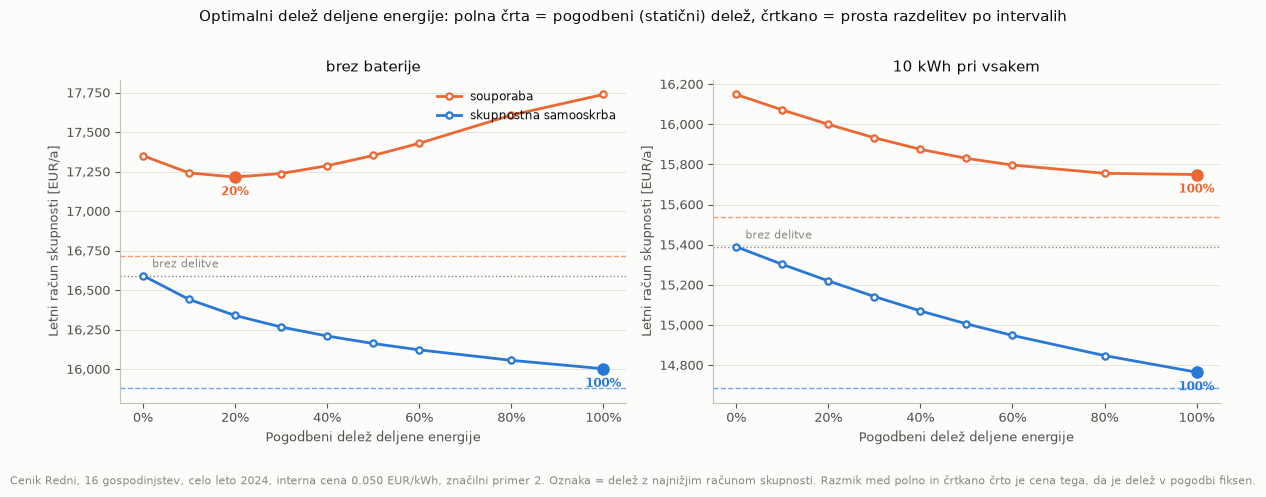

In [22]:
### The share of shared energy -- the figure the study is for
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4))
for ax, battery in zip(axes, SWEEP_BATTERIES):
    baseline = float(ind[ind["battery"] == battery]["Community_cost_EUR"].iloc[0])
    ax.axhline(baseline, color=MUTED, linewidth=1.0, linestyle=":", zorder=1)
    ax.annotate("brez delitve", (0.02, baseline), xytext=(0, 4), textcoords="offset points",
                color=MUTED, fontsize=8, va="bottom")
    for scheme in (ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST):
        sub = sweep[(sweep["battery"] == battery) & (sweep["scheme"] == scheme)
                    ].sort_values("share")
        color = SCHEME_COLOR[scheme]
        ax.plot(sub["share"], sub["Community_cost_EUR"], color=color, linewidth=2.0,
                marker="o", markersize=4.5, markerfacecolor=SURFACE, markeredgewidth=1.6,
                label=SCHEME_LABEL[scheme], zorder=3)
        free = dyn[(dyn["battery"] == battery) & (dyn["scheme"] == scheme)]
        if len(free):
            level = float(free["Community_cost_EUR"].iloc[0])
            ax.axhline(level, color=color, linewidth=1.0, linestyle="--", alpha=0.65, zorder=2)
        best = sub.loc[sub["Community_cost_EUR"].idxmin()]
        ax.plot([best["share"]], [best["Community_cost_EUR"]], marker="o", markersize=8,
                color=color, zorder=4)
        ax.annotate(f"{best['share']:.0%}", (best["share"], best["Community_cost_EUR"]),
                    xytext=(0, -13), textcoords="offset points", ha="center",
                    color=color, fontsize=8.5, fontweight="bold")
    ax.set_title(battery)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.yaxis.set_major_formatter(EUR)
    tidy(ax, "Letni račun skupnosti [EUR/a]", "Pogodbeni delež deljene energije")
axes[0].legend(loc="upper right", fontsize=8.5)
fig.suptitle("Optimalni delež deljene energije: polna črta = pogodbeni (statični) delež, "
             "črtkano = prosta razdelitev po intervalih", y=1.02, fontsize=10.5, color=INK)
fig.text(0.5, -0.06, f"Cenik {MAIN_CONFIG}, {len(HOUSEHOLD_KEYS)} gospodinjstev, celo leto 2024, "
         f"interna cena {INTERNAL_PRICE:.3f} EUR/kWh, značilni primer {ZNACILNI_PRIMER}. "
         f"Oznaka = delež z najnižjim računom skupnosti. Razmik med polno in črtkano črto je "
         f"cena tega, da je delež v pogodbi fiksen.", ha="center", fontsize=8.2, color=MUTED)
plt.tight_layout()
plt.show()

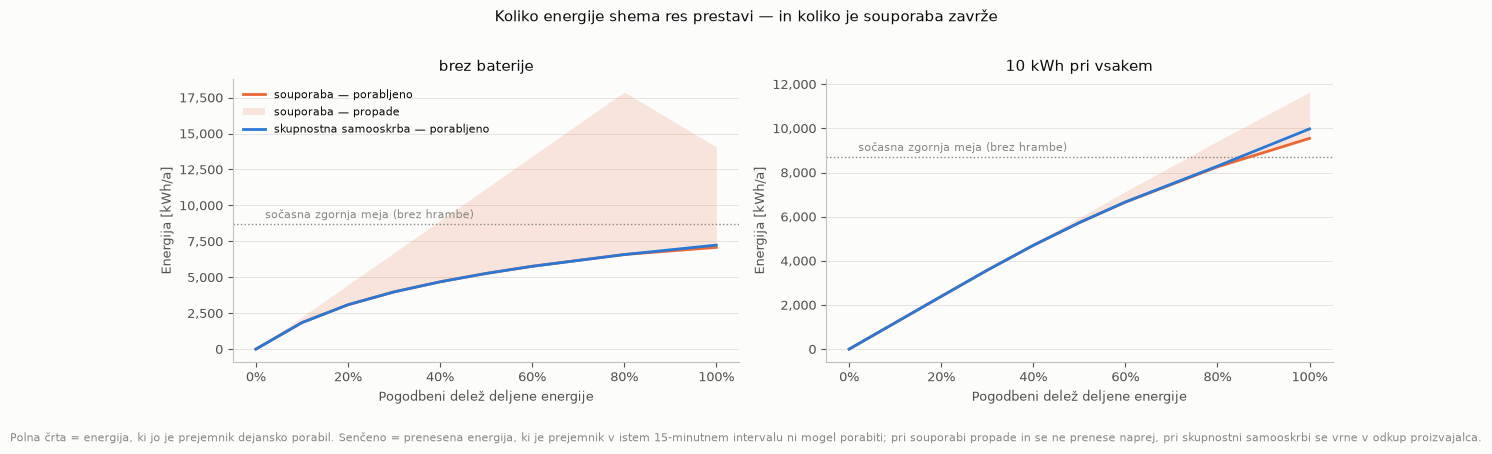

In [23]:
### What souporaba throws away, and community self-supply does not
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.0))
for ax, battery in zip(axes, SWEEP_BATTERIES):
    for scheme in (ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST):
        sub = sweep[(sweep["battery"] == battery) & (sweep["scheme"] == scheme)
                    ].sort_values("share")
        color = SCHEME_COLOR[scheme]
        ax.plot(sub["share"], sub["Shared_kWh"], color=color, linewidth=2.0,
                label=f"{SCHEME_LABEL[scheme]} — porabljeno", zorder=3)
        if sub["Wasted_kWh"].abs().max() > 1.0:
            ax.fill_between(sub["share"], sub["Shared_kWh"],
                            sub["Shared_kWh"] + sub["Wasted_kWh"], color=color, alpha=0.16,
                            linewidth=0, label=f"{SCHEME_LABEL[scheme]} — propade", zorder=2)
    ax.axhline(SHARING_CEILING_KWH, color=MUTED, linestyle=":", linewidth=1.0)
    ax.annotate("sočasna zgornja meja (brez hrambe)", (0.02, SHARING_CEILING_KWH),
                xytext=(0, 4), textcoords="offset points", color=MUTED, fontsize=8)
    ax.set_title(battery)
    ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:.0%}"))
    ax.yaxis.set_major_formatter(EUR)
    tidy(ax, "Energija [kWh/a]", "Pogodbeni delež deljene energije")
axes[0].legend(loc="upper left", fontsize=8)
fig.suptitle("Koliko energije shema res prestavi — in koliko je souporaba zavrže",
             y=1.02, fontsize=10.5, color=INK)
fig.text(0.5, -0.06, "Polna črta = energija, ki jo je prejemnik dejansko porabil. Senčeno = "
         "prenesena energija, ki je prejemnik v istem 15-minutnem intervalu ni mogel porabiti; "
         "pri souporabi propade in se ne prenese naprej, pri skupnostni samooskrbi se vrne v "
         "odkup proizvajalca.", ha="center", fontsize=8.2, color=MUTED)
plt.tight_layout()
plt.show()

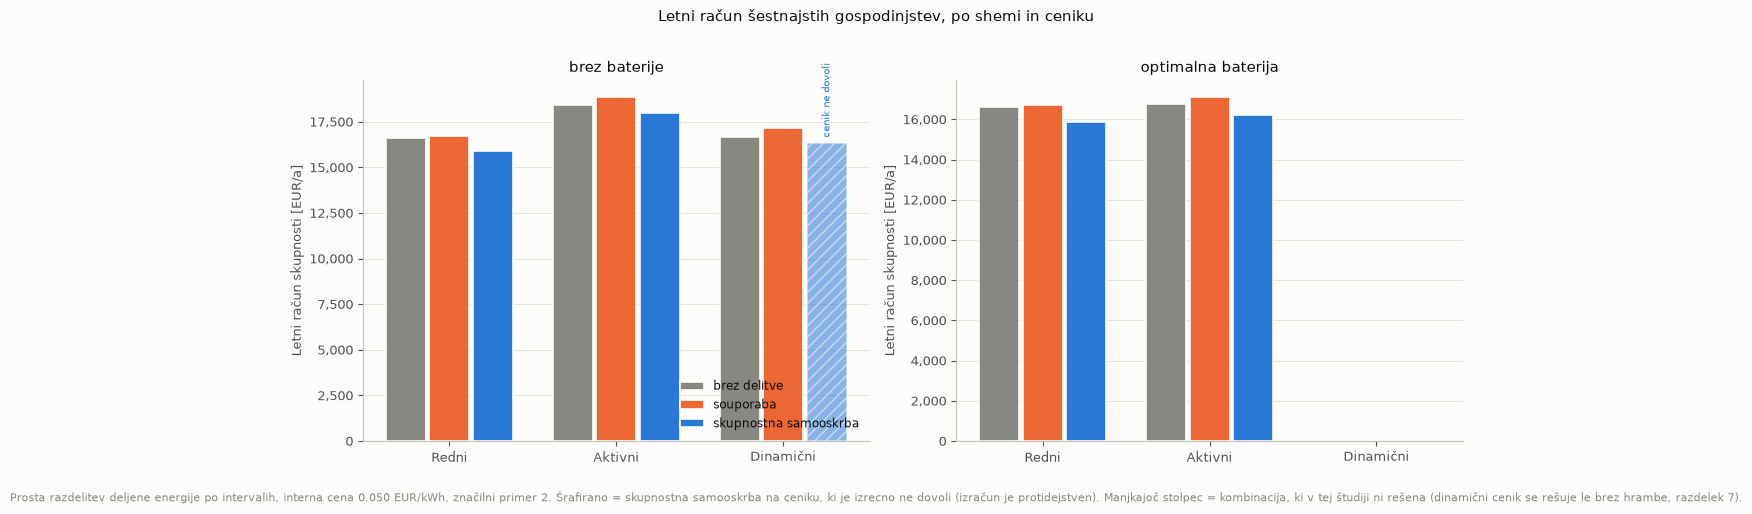

In [24]:
### The community bill, by scheme and price list
fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.6), sharex=True)
order = [ccm.SCHEME_INDIVIDUAL, ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST]
width = 0.26
for ax, battery in zip(axes, BATTERY_SCENARIOS):
    configs = list(LIST_CONFIGS)
    x = np.arange(len(configs))
    for i, scheme in enumerate(order):
        sub = headline[(headline["battery"] == battery) & (headline["scheme"] == scheme)
                       & (headline["sharing"] != ccm.SHARING_STATIC)]
        vals, hatches = [], []
        for c in configs:
            row = sub[sub["config"] == c]
            vals.append(float(row["Community_cost_EUR"].iloc[0]) if len(row) else np.nan)
            hatches.append(scheme == ccm.SCHEME_SKUPNOST and not SKUPNOST_ALLOWED[c])
        bars = ax.bar(x + (i - 1) * width, vals, width * 0.92, color=SCHEME_COLOR[scheme],
                      label=SCHEME_LABEL[scheme], zorder=3, edgecolor=SURFACE, linewidth=1.2)
        for bar, hatched, v in zip(bars, hatches, vals):
            # A missing bar is a configuration this notebook did not solve at
            # this battery scenario (the SIPX-linked pairing, section 7); a
            # hatched one is a configuration the price list forbids.
            if not np.isfinite(v):
                continue
            if hatched:
                bar.set_hatch("///")
                bar.set_alpha(0.55)
                ax.annotate("cenik ne dovoli", (bar.get_x() + bar.get_width() / 2, v),
                            xytext=(0, 4), textcoords="offset points", ha="center",
                            fontsize=7.2, color=SCHEME_COLOR[scheme], rotation=90, va="bottom")
    ax.set_xticks(x)
    ax.set_xticklabels(configs)
    ax.yaxis.set_major_formatter(EUR)
    ax.set_title(battery)
    tidy(ax, "Letni račun skupnosti [EUR/a]")
axes[0].legend(loc="lower right", fontsize=8.5)
fig.suptitle("Letni račun šestnajstih gospodinjstev, po shemi in ceniku", y=1.02,
             fontsize=10.5, color=INK)
fig.text(0.5, -0.05, f"Prosta razdelitev deljene energije po intervalih, interna cena "
         f"{INTERNAL_PRICE:.3f} EUR/kWh, značilni primer {ZNACILNI_PRIMER}. Šrafirano = "
         f"skupnostna samooskrba na ceniku, ki je izrecno ne dovoli (izračun je "
         f"protidejstven). Manjkajoč stolpec = kombinacija, ki v tej študiji ni rešena "
         f"(dinamični cenik se rešuje le brez hrambe, razdelek 7).",
         ha="center", fontsize=8.2, color=MUTED)
plt.tight_layout()
plt.show()

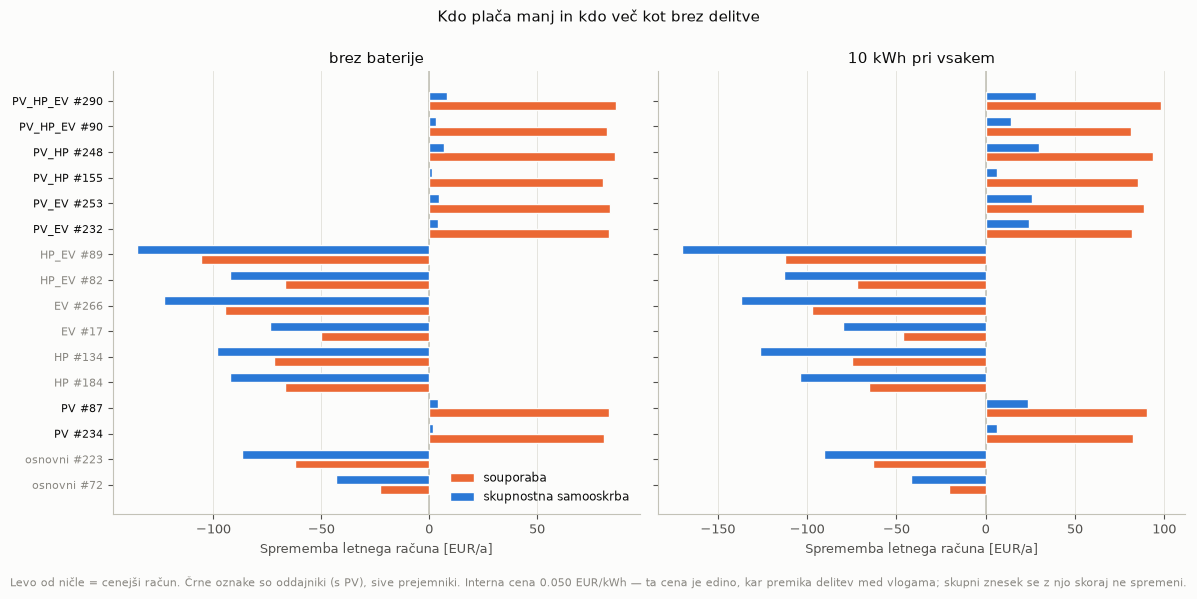

In [25]:
### Who wins and who loses
fig, axes = plt.subplots(1, 2, figsize=(12.0, 5.6), sharey=True)
labels_order = [LABELS[k] for k in HOUSEHOLD_KEYS]
y = np.arange(len(labels_order))
for ax, battery in zip(axes, SWEEP_BATTERIES):
    base = sel[(sel["battery"] == battery) & (sel["scheme"] == ccm.SCHEME_INDIVIDUAL)
               ].set_index("Member")["Cost_EUR"]
    for i, scheme in enumerate((ccm.SCHEME_SOUPORABA, ccm.SCHEME_SKUPNOST)):
        sub = sel[(sel["battery"] == battery) & (sel["scheme"] == scheme)].set_index("Member")
        delta = (sub["Cost_EUR"] - base).reindex(labels_order)
        ax.barh(y + (i - 0.5) * 0.38, delta, 0.35, color=SCHEME_COLOR[scheme],
                label=SCHEME_LABEL[scheme], zorder=3, edgecolor=SURFACE, linewidth=1.0)
    ax.axvline(0, color=BASELINE, linewidth=1.2)
    ax.set_yticks(y)
    ax.set_yticklabels(labels_order, fontsize=8)
    ax.invert_yaxis()
    ax.set_title(battery)
    ax.grid(axis="x", linewidth=0.6)
    ax.set_axisbelow(True)
    ax.set_xlabel("Sprememba letnega računa [EUR/a]")
# The role is carried by the tick label's ink, so it survives being read in
# black and white. Only the left panel draws labels -- the axes share a y -- so
# this walks the ticks it finds rather than assuming both panels have them.
for ax in axes:
    ticklabels = ax.get_yticklabels()
    for i, k in enumerate(HOUSEHOLD_KEYS):
        if i < len(ticklabels):
            ticklabels[i].set_color(INK if HAS_PV[k] else MUTED)
axes[0].legend(loc="lower right", fontsize=8.5)
fig.suptitle("Kdo plača manj in kdo več kot brez delitve", y=1.0, fontsize=10.5, color=INK)
fig.text(0.5, -0.03, f"Levo od ničle = cenejši račun. Črne oznake so oddajniki (s PV), sive "
         f"prejemniki. Interna cena {INTERNAL_PRICE:.3f} EUR/kWh — ta cena je edino, kar "
         f"premika delitev med vlogama; skupni znesek se z njo skoraj ne spremeni.",
         ha="center", fontsize=8.2, color=MUTED)
plt.tight_layout()
plt.show()

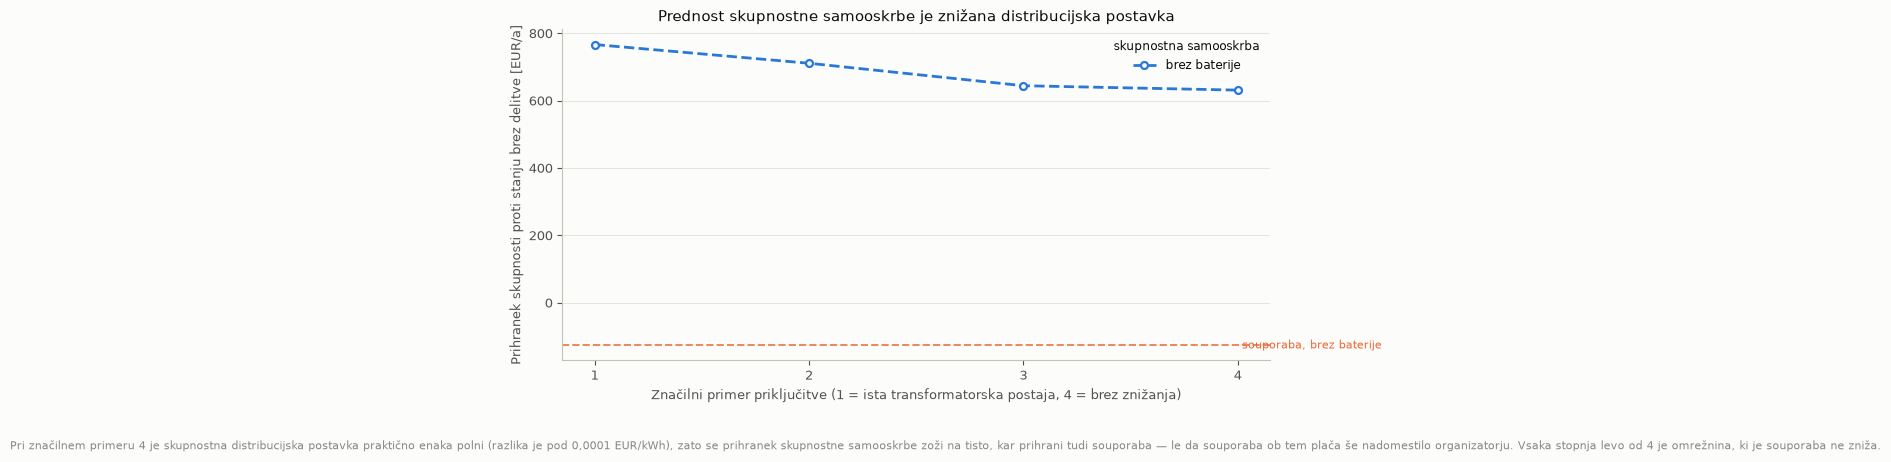

In [26]:
### How much of the community-self-supply advantage is the network discount
fig, ax = plt.subplots(figsize=(9.0, 4.2))
zp_runs = runs[(runs["scheme"] == ccm.SCHEME_SKUPNOST) & (runs["config"] == MAIN_CONFIG)
               & (runs["sharing"] == ccm.SHARING_DYNAMIC)
               & (runs["internal_price"] == INTERNAL_PRICE)]
for battery in [SENSITIVITY_BATTERY]:
    sub = zp_runs[zp_runs["battery"] == battery].sort_values("znacilni_primer")
    baseline = float(ind[ind["battery"] == battery]["Community_cost_EUR"].iloc[0])
    ax.plot(sub["znacilni_primer"], baseline - sub["Community_cost_EUR"],
            color=SCHEME_COLOR[ccm.SCHEME_SKUPNOST], linewidth=2.0,
            linestyle=BATTERY_STYLE[battery], marker="o", markersize=5,
            markerfacecolor=SURFACE, markeredgewidth=1.6, label=battery, zorder=3)
souporaba_level = {
    battery: float(ind[ind["battery"] == battery]["Community_cost_EUR"].iloc[0])
    - float(dyn[(dyn["battery"] == battery) & (dyn["scheme"] == ccm.SCHEME_SOUPORABA)
                ]["Community_cost_EUR"].iloc[0])
    for battery in [SENSITIVITY_BATTERY]}
for battery, level in souporaba_level.items():
    ax.axhline(level, color=SCHEME_COLOR[ccm.SCHEME_SOUPORABA], linewidth=1.4,
               linestyle=BATTERY_STYLE[battery], alpha=0.8)
    ax.annotate(f"souporaba, {battery}", (4.02, level), fontsize=8,
                color=SCHEME_COLOR[ccm.SCHEME_SOUPORABA], va="center")
ax.set_xticks(ZNACILNI_PRIMER_GRID)
ax.yaxis.set_major_formatter(EUR)
ax.legend(loc="upper right", fontsize=8.5, title="skupnostna samooskrba", title_fontsize=8.5)
tidy(ax, "Prihranek skupnosti proti stanju brez delitve [EUR/a]",
     "Značilni primer priključitve (1 = ista transformatorska postaja, 4 = brez znižanja)")
ax.set_title("Prednost skupnostne samooskrbe je znižana distribucijska postavka")
fig.text(0.5, -0.08, "Pri značilnem primeru 4 je skupnostna distribucijska postavka praktično "
         "enaka polni (razlika je pod 0,0001 EUR/kWh), zato se prihranek skupnostne samooskrbe "
         "zoži na tisto, kar prihrani tudi souporaba — le da souporaba ob tem plača še "
         "nadomestilo organizatorju. Vsaka stopnja levo od 4 je omrežnina, ki je souporaba ne "
         "zniža.", ha="center", fontsize=8.2, color=MUTED)
plt.tight_layout()
plt.show()

## 10. Read-out

In [27]:
best_soup = optimum_table[optimum_table["Shema"] == ccm.SCHEME_SOUPORABA]
best_skup = optimum_table[optimum_table["Shema"] == ccm.SCHEME_SKUPNOST]
sized = UNIFORM_BATTERY_LABEL
row_soup = best_soup[best_soup["Baterija"] == sized].iloc[0]
row_skup = best_skup[best_skup["Baterija"] == sized].iloc[0]
flat_soup = best_soup[best_soup["Baterija"] == "brez baterije"].iloc[0]
flat_skup = best_skup[best_skup["Baterija"] == "brez baterije"].iloc[0]

lines = [
    f"{len(HOUSEHOLD_KEYS)} households ({len(SENDER_KEYS)} with a PV device, "
    f"{len(RECEIVER_KEYS)} without), whole of 2024, {N_STEPS_YEAR:,} intervals of "
    f"{step_minutes:.0f} min, {len(runs)} whole-year runs of "
    f"{len(MONTH_SLICES)} community MILPs each",
    f"Community load {profile_table['Poraba_kWh'].sum():,.0f} kWh/a against "
    f"{profile_table['Proizvodnja_kWh'].sum():,.0f} kWh/a of production; the producers' surplus "
    f"is {TOTAL_SURPLUS_KWH:,.0f} kWh/a and only {SHARING_CEILING_KWH:,.0f} kWh/a of it "
    f"({100 * SHARING_CEILING_KWH / TOTAL_SURPLUS_KWH:.0f} %) is coincident with a consumer's "
    f"offtake without storage -- that is the ceiling every scheme is measured against",
    "",
    "THE DIFFERENCE BETWEEN THE SCHEMES",
    f"A shared kWh is worth {float(value_table[value_table['Cenik'] == MAIN_CONFIG]['Souporaba_EUR_kWh'].iloc[0]):.4f} EUR "
    f"under souporaba and "
    f"{float(value_table[value_table['Cenik'] == MAIN_CONFIG]['Skupnostna_EUR_kWh'].iloc[0]):.4f} EUR "
    f"under community self-supply on the {MAIN_CONFIG} pairing at midday -- the whole gap is the "
    f"distribution part of the network tariff, which souporaba keeps charging in full",
    f"Souporaba also pays {STORITVE_SOUPORABE[SOUPORABA_SERVICE].organizator} "
    f"{annual_fee:,.0f} EUR/a with VAT for organizing the scheme; community self-supply pays "
    f"nobody, and that fee is a fixed cost the sharing has to earn back before it is worth "
    f"anything",
    f"And souporaba destroys what nobody used in the same interval: at the ZOEE-optimal share it "
    f"wastes {row_soup['Zavrženo_kWh']:,.0f} kWh/a with batteries and "
    f"{flat_soup['Zavrženo_kWh']:,.0f} kWh/a without, where community self-supply wastes nothing "
    f"-- unused allocation goes back to the producers' buyback",
    "",
    "THE SHARE OF SHARED ENERGY",
    f"With batteries, the community bill bottoms out at a contract share of "
    f"{row_soup['Optimalni_delež']:.0%} for souporaba and {row_skup['Optimalni_delež']:.0%} for "
    f"community self-supply; without batteries at {flat_soup['Optimalni_delež']:.0%} and "
    f"{flat_skup['Optimalni_delež']:.0%}",
    f"Writing that share into a contract instead of letting the allocation move per interval "
    f"costs {row_soup['Cena_statičnosti_EUR']:,.0f} EUR/a (souporaba) and "
    f"{row_skup['Cena_statičnosti_EUR']:,.0f} EUR/a (community self-supply) on the sized "
    f"community -- the price of a rule that cannot see whether anyone is drawing power",
    "",
    "WHAT EITHER SCHEME IS WORTH",
    (f"At its own optimal share, community self-supply takes "
     f"{row_skup['Prihranek_EUR']:,.0f} EUR/a off the sized community's bill "
     f"({flat_skup['Prihranek_EUR']:,.0f} without batteries), while souporaba "
     + ("ADDS" if row_soup['Prihranek_EUR'] < 0 else "takes off") +
     f" {abs(row_soup['Prihranek_EUR']):,.0f} EUR/a "
     f"({abs(flat_soup['Prihranek_EUR']):,.0f} without) -- the organizer's fee of "
     f"{annual_fee:,.0f} EUR/a is larger than everything souporaba's per-kWh saving can "
     f"recover at this community's volumes"),
    f"Per household that is {row_skup['Prihranek_EUR'] / len(HOUSEHOLD_KEYS):,.0f} EUR/a on "
    f"average for the better of the two -- against an average annual bill of "
    f"{float(ind[ind['battery'] == sized]['Community_cost_EUR'].iloc[0]) / len(HOUSEHOLD_KEYS):,.0f} EUR",
    "",
    "WHO PAYS FOR IT",
    f"At an internal price of {INTERNAL_PRICE:.3f} EUR/kWh the two roles land on opposite sides: "
    + "; ".join(f"{r['Shema']} -- producers {r['Oddajniki_EUR']:+,.0f} EUR/a, consumers "
                f"{r['Prejemniki_EUR']:+,.0f} EUR/a"
                for _, r in split[split['Baterija'] == sized].iterrows()),
    f"The price both sides can live with runs from "
    + "; ".join(f"{r['Shema']} {r['Spodnja_meja_EUR_kWh']:.4f} to {r['Zgornja_meja_EUR_kWh']:.4f} EUR/kWh"
                for _, r in bracket[bracket['Baterija'] == sized].iterrows())
    + " -- below the floor the producer would rather sell to its supplier, above the ceiling the "
      "consumer would rather buy from its own",
    f"Every euro of internal price costs the community {DDV:.0%} of itself in VAT, because the "
    f"consumer is invoiced for it and the producer is credited without it. The community-optimal "
    f"internal price is therefore exactly 0.00, and any positive value is a fairness decision "
    f"paid for at 22 cents on the euro",
    "",
    "AGAINST THE OPTIONS EACH HOUSEHOLD ALREADY HAS",
    (lambda best: (
        f"Every household on its own best selectable list and its own best battery costs "
        f"{OWN_BEST_TOTAL:,.0f} EUR/a including capex (sizing study). The cheapest COMMUNITY "
        f"arrangement costs {best['Neto_strošek_EUR']:,.0f} EUR/a "
        f"({best['Cenik']}, {best['Shema']}, {best['Baterija']}), i.e. "
        f"{abs(best['Proti_lastni_izbiri_EUR']):,.0f} EUR/a "
        + ("MORE" if best['Proti_lastni_izbiri_EUR'] > 0 else "less") +
        f" than leaving the sixteen households to choose for themselves. Pinning a community to "
        f"one product family costs more than either sharing scheme gives back"
    ))(levels[levels["Raven"] != "1. lastna najboljša izbira (študija dimenzioniranja)"]
       .sort_values("Neto_strošek_EUR").iloc[0]),
    f"GEN-I's dinamični samooskrba list -- the cheapest list in the sizing study -- carries "
    f"dovoljuje_skupnostno=False and cannot be held inside a community self-supply scheme at "
    f"all. A community on that list has souporaba and nothing else; a community that wants "
    f"community self-supply has to move its producers onto a more expensive list first, and "
    f"section 8.4 prices that move",
]
print("\n".join(lines))

16 households (8 with a PV device, 8 without), whole of 2024, 35,136 intervals of 15 min, 81 whole-year runs of 12 community MILPs each
Community load 91,526 kWh/a against 22,972 kWh/a of production; the producers' surplus is 22,362 kWh/a and only 8,724 kWh/a of it (39 %) is coincident with a consumer's offtake without storage -- that is the ceiling every scheme is measured against

THE DIFFERENCE BETWEEN THE SCHEMES
A shared kWh is worth 0.0924 EUR under souporaba and 0.1017 EUR under community self-supply on the Redni pairing at midday -- the whole gap is the distribution part of the network tariff, which souporaba keeps charging in full
Souporaba also pays GEN-I 700 EUR/a with VAT for organizing the scheme; community self-supply pays nobody, and that fee is a fixed cost the sharing has to earn back before it is worth anything
And souporaba destroys what nobody used in the same interval: at the ZOEE-optimal share it wastes 2,099 kWh/a with batteries and 1,385 kWh/a without, where com

### Caveats worth keeping in view* **Perfect foresight, and a central operator.** The MILP knows the whole year and minimizes the  community's total, which is what a community *operator* would do, not what sixteen households  negotiating separately would reach. Every saving here is an upper bound twice over: no  controller does better than perfect foresight, and no voluntary arrangement does better than  a benevolent central one.* **The monthly decomposition.** The year is twelve solves, each opening and closing at half  charge. Section 6 measures what that costs on a sized household; it is the same penalty in  every scheme, so it cancels in every comparison between them, but the absolute bills carry it.* **One role per member.** A producer never receives allocation from another producer. In this  community that costs little — the eight producers export at the same times as each other — but  in a group with a mix of orientations or a wind device it would matter, and modelling it needs  the buy/sell binary the module deliberately avoids.* **Every producer on one price list.** The sharing pool settles unused and consumed allocation at  a single buyback price, which is exact only if the producers hold the same list. A community  whose producers are with different suppliers — legal under ZOEE — needs the pool split per  producer.* **Two excess-power rules live in this repository, and this notebook uses one of them.**  `si_obracun.MesecniObracun` charges the root-mean-square of every quarter-hour above the agreed  power and puts it in the taxable base; `si_konica`, `MILP_Benchmark` and this module charge the  single highest quarter-hour and add it without VAT. Section 6 measures the gap. It is the same  item under two readings of the Akt, it is identical in every scheme here, and it cancels in  every comparison between them — but the absolute bills carry whichever rule is in force.* **The peak charge is measured on the metered offtake, in both schemes.** `si_obracun.skupnost`  measures the billed power on the offtake *net* of the community allocation, which would make  sharing reduce the excess-power charge as well. That is not what a meter can do — the  allocation is applied after the fact — so this notebook bills power on the full metered  quantity. Everything else in the settlement reconciles with `si_obracun` to the cent  (section 6).* **Neither scheme's own costs are modelled beyond the tariff.** Souporaba's organizer fee is in  the bill because GEN-I publishes it. Community self-supply's setup — the community entity, its  registration, the metering agreement — is not, because there is no published price list for it.  A community self-supply saving of a few hundred euro a year is not obviously bigger than the  administration it takes to run one.* **2024 volumes, 2026 tariffs.** The profiles are 2024 and the regulatory regime is  `PRICING_REFERENCE_YEAR = 2026`. That is deliberate — the question is what these households  would pay under the rules now in force — but it means the SIPX series and the tariff act come  from different years.* **The Fluvius timestamps are Brussels local time written with a `Z`.** Every interval sits one  to two hours off the Slovenian tariff clock, which shifts which block a kWh falls in. It  affects both schemes identically.